Loading packages

In [90]:
#loading packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import networkx as nx
import seaborn as sns
from geopy.distance import geodesic
from scipy.stats import pearsonr
from pathlib import Path
import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import importlib
import os
import sys
from statsmodels.tsa.stattools import adfuller, kpss
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Locate the project root regardless of where the notebook is executed from
cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "external").exists():
    project_root = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "external").exists():
    project_root = cwd.parent
else:
    raise RuntimeError("Could not locate the project root.")

sys.path.append(str(project_root / "external"))
sys.path.append(str(project_root / "src"))

import diagnostics
importlib.reload(diagnostics)
import real_data_pipeline
importlib.reload(real_data_pipeline)
import simulation
importlib.reload(simulation)
import edge_baselines
importlib.reload(edge_baselines)


from real_data_pipeline import (build_baboon_edge_graph, run_baseline_comparison,
                                 run_gnar_edge_rolling_multicov, edge_weights_distribution,
                                 run_full_sweep, build_stages_per_lag, get_winner_and_loser,
                                 full_mase_sweep, compute_naive_baseline_mae, make_bidirectional_pairs)
from BaseEdgeGNAR_edge import GNAREdgeLearner
from BaseEdgeGNAR_edge_global import GNAREdgeGlobalLearner
from edge_graph import ArrayEdgeGraph
from RollingEdgePredict import RollingEdgePredict
from model import build_edge_covariate, GNAREdgeGlobalMultiCovLearner
from diagnostics import save_table, run_residual_diagnostics_pooled, save_figure, time_call
from edge_baselines import (to_edge_graph, NaiveEdgeBaseline, ZeroEdgeBaseline,
                            ARIMAEdgeBaseline, SARIMAEdgeBaseline, DFMEdgeBaseline,
                            compare_baselines, dfm_pca_one_step)


from simulation import (
    # Network generation
    calibrate_rdp_radius,
    get_or_calibrate_rdp_radius,
    generate_network,
    simulate_node_covariates,
    build_synthetic_edge_covariates,

    # Time-series simulation
    simulate_ar1_exog,
    simulate_full_model,

    # Graph and design-matrix utilities
    build_W_matrices,
    build_design_matrix,
    compute_ols_standard_errors,

    # Monte Carlo simulation
    run_full_simulation_replication,
    run_large_network_replication_density,
    run_single_step_prediction_replication,
    run_single_step_prediction_replication_learner,
    run_single_step_prediction_replication_with_dfm,
    run_dgp_fixed_model_comparison_replication,

    # Regime construction
    expand_R_by_l,
    build_beta_dict,
    build_regime,

    # Results tables
    build_per_parameter_table,
    build_aggregated_table4_style,

    # Small helper
    format_tuple_list,
    format_as_multiindex,
    run_fixed_network_replication
)

#loading external data
interactions_path = project_root / "data" / "baboons_proximity_data.txt"
max_temp_path = project_root / "data" / "trets.csv"
baboon_data_path = project_root / "data" / "baboon_data.csv"

figures_dir = project_root / "notebooks" / "output" / "figures"
tables_dir = project_root / "notebooks" / "output" / "tables"

Creating demographic lookup tables and lagged exogenous series

In [2]:
#age and gender data
baboon_data = pd.read_csv(
    baboon_data_path,
    parse_dates=["dob"],
    dayfirst= True
)
baboon_df = pd.DataFrame(baboon_data)

#defining ages
study_start = pd.to_datetime("2019-06-13")
baboon_df['dob'] = pd.to_datetime(baboon_df['dob'], format='%d-%m-%Y')
baboon_df['age'] = (study_start - baboon_df['dob']).dt.days / 365.25

age_lookup = dict(zip(baboon_df["name"], baboon_df["age"]))
sex_lookup = dict(zip(baboon_df["name"], baboon_df["sex"]))

#temperature data (called trets because this is the name of the weather station)
trets = pd.read_csv(
    max_temp_path,
    sep = ";",
    decimal= ","
)

#filtering columns
cols = [
    "DATE",
    "RR",      # rainfall (mm)
    "TN",      # minimum temperature
    "TX",      # maximum temperature
    "TM",      # mean temperature
    "UM",      # mean relative humidity
    "FFM"      # mean wind speed
]

trets = trets[cols]

trets["DATE"] = pd.to_datetime(
    trets["DATE"],
    format= "%Y%m%d"
)
#renaming columns
rename = {
    "RR": "rainfall_mm",
    "TN": "temp_min",
    "TX": "temp_max",
    "TM": "temp_mean",
    "UM": "humidity",
    "FFM": "wind_speed",
}

trets = trets.rename(columns = rename)

weather = pd.DataFrame(trets)
weather = weather.set_index("DATE").sort_index()

temp_lag1 = weather["temp_max"].shift(1)


Defining arguments for extended GNAR-edge model

In [3]:

base_kwargs_fixed = dict(
    timestamp="1D", transform="difference", standardize=False, edge_threshold=1.0,
    n_rolling_test=5, weight_mode="proportion_edges",
    path=interactions_path,
    age_lookup=age_lookup, sex_lookup=sex_lookup,
)

configs = [
    {"label": "no_covariates", "edge_cov_kinds": [], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "temp_only", "edge_cov_kinds": [], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},
    {"label": "age_diff_only", "edge_cov_kinds": ["abs_diff"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "mean_age_only", "edge_cov_kinds": ["mean"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "same_sex_only", "edge_cov_kinds": ["same_sex"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "mean_age_temp", "edge_cov_kinds": ["mean"], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},
    {"label": "age_diff_temp", "edge_cov_kinds": ["abs_diff"], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},  # Fixed missing bracket
    {"label": "age_diff_mean_age", "edge_cov_kinds": ["abs_diff", "mean"], "exog_series_dict": {}, "interaction_pairs": []},
    {
        "label": "age_diff_mean_age_temp_no_interaction",
        "edge_cov_kinds": ["abs_diff", "mean"], 
        "exog_series_dict": {"temp_max_lag1": temp_lag1}, 
        "interaction_pairs": []
    },
    {
        "label": "age_diff_mean_age_temp_with_interaction",
        "edge_cov_kinds": ["abs_diff", "mean"], 
        "exog_series_dict": {"temp_max_lag1": temp_lag1},
        "interaction_pairs": [("mean_age", "temp_max_lag1")]
    },
    {"label": "temp_same_sex", "edge_cov_kinds": ["same_sex"], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},
    {"label": "age_diff_same_sex", "edge_cov_kinds": ["abs_diff", "same_sex"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "mean_age_same_sex", "edge_cov_kinds": ["mean", "same_sex"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "mean_age_temp_same_sex", "edge_cov_kinds": ["mean", "same_sex"], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},
    {"label": "age_diff_temp_same_sex", "edge_cov_kinds": ["abs_diff", "same_sex"], "exog_series_dict": {"temp_max_lag1": temp_lag1}, "interaction_pairs": []},
    {"label": "age_diff_mean_age_same_sex", "edge_cov_kinds": ["abs_diff", "mean", "same_sex"], "exog_series_dict": {}, "interaction_pairs": []},
    {"label": "age_diff_mean_age_temp_same_sex_no_interaction",
     "edge_cov_kinds": ["abs_diff", "mean", "same_sex"],
     "exog_series_dict": {"temp_max_lag1": temp_lag1},
     "interaction_pairs": []},
    {"label": "age_diff_mean_age_temp_same_sex_with_interaction",
     "edge_cov_kinds": ["abs_diff", "mean", "same_sex"],
     "exog_series_dict": {"temp_max_lag1": temp_lag1},
     "interaction_pairs": [("mean_age", "temp_max_lag1")]},
]

interaction_cfg = {"label": "age_diff_mean_age_temp_same_sex_with_interaction",
     "edge_cov_kinds": ["abs_diff", "mean", "same_sex"],
     "exog_series_dict": {"temp_max_lag1": temp_lag1},
     "interaction_pairs": [("mean_age", "temp_max_lag1")]}

Experimenting with shorter aggregation windows

In [4]:
#building a graph with 12H aggregation windows
twelve_hour_agg = edge_weights_distribution(timestamp="12h", 
                                            verbose = False,
                                            path = interactions_path)
twelve_hour_agg_edges = twelve_hour_agg["summary"]["n_edges"]


#building a graph with 48H aggregation windows
fortyeight_hour_agg = edge_weights_distribution(timestamp="2D", 
                                            verbose = False,
                                            path = interactions_path)
fortyeight_hour_agg_serieslength = len(fortyeight_hour_agg["windows"])


print("Number of edges for a 12 hour aggregation period:", twelve_hour_agg_edges)
print("Length of time series for a 48 hour aggregation period:", fortyeight_hour_agg_serieslength)

[GNAREdgeGlobalLearner] epoch=001 loss=1273.19893828 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1273.198938283437 train_set_time=nans fit_time=0.002s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1272.75768625 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1272.7576862487047 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1293.81148904 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1293.8114890436368 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1278.04432942 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1278.0443294236657 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] e

***Preprocessing of the time series***

Distribution of edge weights before preprocessing vs after preprocessing

[GNAREdgeGlobalLearner] epoch=001 loss=1466.67454034 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1466.6745403398702 train_set_time=nans fit_time=0.016s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1451.67779800 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1451.6777980036825 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1414.20512212 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1414.205122119318 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] epoch=001 loss=1379.42063980 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalLearner] fit_done epochs=1 best_epoch=1 best_loss=1379.4206398004792 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalLearner] e

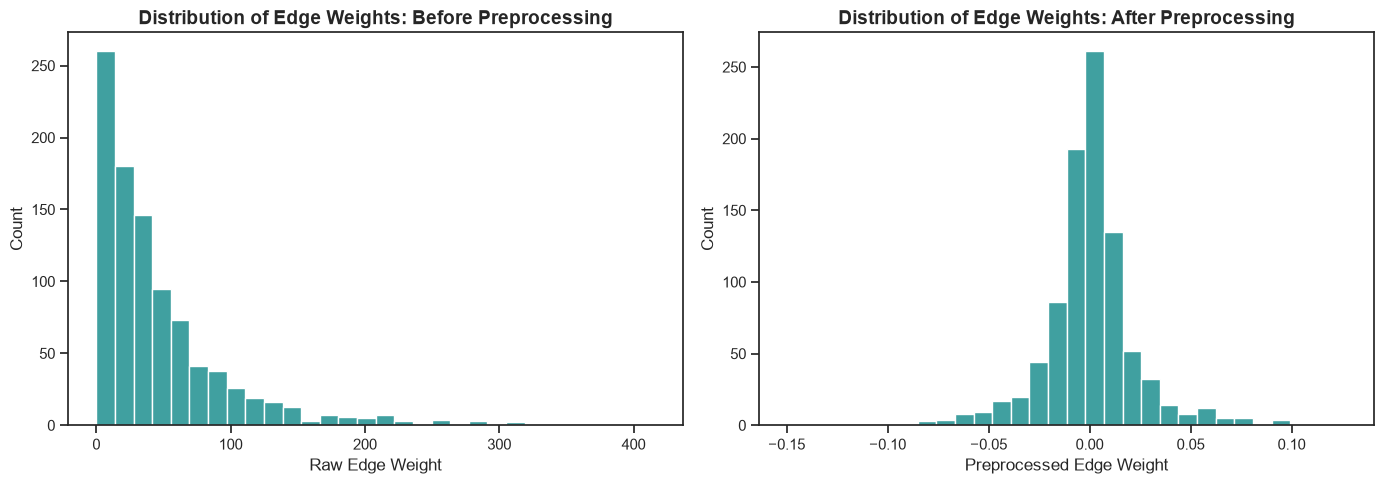

In [40]:

sns.set_theme(style="ticks")

# before preprocessing data
out_before = edge_weights_distribution(
    timestamp="1D",
    weight_mode="count",   
    transform="none",         
    path=interactions_path,
)
weights_before = out_before["edge_weight_model_df"].values.flatten()

# after preprocessing data
out_after = edge_weights_distribution(
    timestamp="1D",
    weight_mode="proportion_edges",   
    transform="difference",         
    path=interactions_path,
)
weights_after = out_after["edge_weight_model_df"].values.flatten()

# side by side histograms
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# plot 1: before preprocessing
sns.histplot(weights_before, bins=30, color="teal", ax=ax[0])
ax[0].set_title("Distribution of Edge Weights: Before Preprocessing", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Raw Edge Weight", fontsize=12)
ax[0].set_ylabel("Count", fontsize=12)

# plot 2: after preprocessing
sns.histplot(weights_after, bins=30, color="teal", ax=ax[1])
ax[1].set_title("Distribution of Edge Weights: After Preprocessing", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Preprocessed Edge Weight", fontsize=12)
ax[1].set_ylabel("Count", fontsize=12)

plt.tight_layout()
save_figure(fig, "edge_weight_distribution_before_after")
plt.show()

Investigating stationarity of the time series

In [91]:

stationarity_results = []
#collecting stationarity results for each edge
for edge_name in out_before["edge_weight_level_df"].columns:
    series = out_before["edge_weight_level_df"][edge_name]

    # ADF: null hypothesis = unit root / non-stationary
    adf_stat, adf_p, *_ = adfuller(series)

    # KPSS: null hypothesis = stationary
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")

    stationarity_results.append({
        "edge": edge_name,
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "adf_fail_to_reject": adf_p > 0.05,
        "kpss_fail_to_reject": kpss_p > 0.05,
    })

stationarity_df = pd.DataFrame(stationarity_results)

print(
    "ADF fails to reject non-stationarity:",
    stationarity_df["adf_fail_to_reject"].sum(),
    f"({100 * stationarity_df['adf_fail_to_reject'].mean():.1f}%)"
)

print(
    "KPSS fails to reject stationarity:",
    stationarity_df["kpss_fail_to_reject"].sum(),
    f"({100 * stationarity_df['kpss_fail_to_reject'].mean():.1f}%)"
)

#diagnosis inconclusive when the tests disagree
stationarity_df["diagnosis"] = "inconclusive"

stationarity_df.loc[
    (stationarity_df["adf_p"] <= 0.05) &
    (stationarity_df["kpss_p"] > 0.05),
    "diagnosis"
] = "evidence stationary"

stationarity_df.loc[
    (stationarity_df["adf_p"] > 0.05) &
    (stationarity_df["kpss_p"] <= 0.05),
    "diagnosis"
] = "evidence nonstationary"

display(stationarity_df)

ADF fails to reject non-stationarity: 9 (26.5%)
KPSS fails to reject stationarity: 31 (91.2%)


/var/folders/sj/s0ncj4tn3ll32fnddwddmnbw0000gn/T/ipykernel_42470/2021072405.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/sj/s0ncj4tn3ll32fnddwddmnbw0000gn/T/ipykernel_42470/2021072405.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/sj/s0ncj4tn3ll32fnddwddmnbw0000gn/T/ipykernel_42470/2021072405.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/var/folders/sj/s0ncj4tn3ll32fnddwddmnbw000

,edge,adf_p,kpss_p,adf_fail_to_reject,kpss_fail_to_reject,diagnosis
0,ANGELE-ARIELLE,8.301600e-02,0.100000,True,True,inconclusive
1,ANGELE-EWINE,1.714926e-04,0.100000,False,True,evidence stationary
2,ANGELE-FANA,8.749578e-04,0.100000,False,True,evidence stationary
3,ANGELE-FELIPE,5.601974e-01,0.100000,True,True,inconclusive
4,ANGELE-FEYA,1.411048e-06,0.100000,False,True,evidence stationary
5,ANGELE-HARLEM,4.238814e-01,0.100000,True,True,inconclusive
6,ANGELE-PETOULETTE,2.111686e-04,0.100000,False,True,evidence stationary
7,ARIELLE-EWINE,9.141837e-02,0.100000,True,True,inconclusive
8,ARIELLE-FANA,6.766678e-03,0.100000,False,True,evidence stationary
9,ARIELLE-FELIPE,9.165023e-04,0.100000,False,True,evidence stationary


***Comparing GNAR-edge model across lags, neighbour stages and covariate configurations***

Fitting the model across lag, stage, covariate specifications

In [54]:
#lags and neighbour stages under consideration
L_values = list(range(1, 9))     # l = 1,...,9
r_values = list(range(0, 3))      # r = 0,...,4

#running sweep across lags and neighbour stages
sweep_df = run_full_sweep(configs, L_values, r_values, base_kwargs_fixed)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00048371 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00048370671716938213 train_set_time=nans fit_time=0.020s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00047042 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00047041555837680266 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00045911 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0004591056154314469 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00045017 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0004501672619573098 train_set_time=

Result summary tables

In [55]:
#1. best (L, r) within each covariate config
best_within_config = (
    sweep_df.loc[sweep_df.groupby("covariate_config")["mean_RMSE"].idxmin()]
    .sort_values("mean_RMSE")
)
print("best (L, r) within each covariate config")
save_table(best_within_config.round(4), "real_data_best_lag_stage_by_config")
display(best_within_config)

#2. overall ranking across all (config, L, r) combinations
overall_ranking = sweep_df.sort_values("mean_RMSE").reset_index(drop=True)
print("overall ranking across all (config, L, r) combinations")
save_table(overall_ranking.round(4), "real_data_overall_lag_stage_config_ranking")
display(overall_ranking.head(20))

#3. for a fixed (L, r), compare covariate configs against each other
fixed_L_r = sweep_df[(sweep_df["L"] == 6) & (sweep_df["r"] == 2)].sort_values("mean_RMSE")
print("for a fixed (L, r), compare covariate configs against each other")
save_table(fixed_L_r.round(4), "real_data_lag6_stage2_config_comparison")
display(fixed_L_r)

#4. heatmap-style view: mean RMSE by (L, r), for one covariate config
one_config = sweep_df[sweep_df["covariate_config"] == "no_covariates"]
pivot = one_config.pivot(index="r", columns="L", values="mean_RMSE")
print(" heatmap-style view: mean RMSE by (L, r), for ONE covariate config")
display(pivot)

#5. average RMSE per covariate config, marginalising over L and r
avg_by_config = sweep_df.groupby("covariate_config")["mean_RMSE"].mean().sort_values()
print("average RMSE per covariate config, marginalising over L and r")
display(avg_by_config)

#6. average RMSE per (L, r), marginalising over covariate config
avg_by_L_r = sweep_df.groupby(["L", "r"])["mean_RMSE"].mean().reset_index()
pivot_avg = avg_by_L_r.pivot(index="r", columns="L", values="mean_RMSE")
print("average RMSE per (L, r), marginalising over covariate config")
display(pivot_avg)

best (L, r) within each covariate config


,covariate_config,L,r,mean_MAE,mean_RMSE,std_MAE,std_RMSE,n_covariates
323,age_diff_mean_age_temp_same_sex_with_interaction,6,2,18.804536,25.580106,5.029975,6.535742,5
315,age_diff_mean_age_temp_with_interaction,6,2,18.667016,25.595848,4.879504,6.525257,4
281,age_diff_same_sex,6,0,18.802949,25.625701,5.122153,6.608017,2
286,age_diff_mean_age_temp_same_sex_no_interaction,6,0,18.807911,25.649670,5.105893,6.636986,4
276,age_diff_temp,6,0,18.705329,25.657104,4.933293,6.603899,2
283,mean_age_temp_same_sex,6,0,18.804131,25.657749,5.109115,6.653940,3
278,age_diff_mean_age_temp_no_interaction,6,0,18.703347,25.662927,4.940491,6.618813,3
285,age_diff_mean_age_same_sex,6,0,18.810163,25.671465,5.141608,6.677061,3
277,age_diff_mean_age,6,0,18.713954,25.671659,4.951442,6.633216,2
282,mean_age_same_sex,6,0,18.803789,25.685544,5.151707,6.705387,2


overall ranking across all (config, L, r) combinations


,covariate_config,L,r,mean_MAE,mean_RMSE,std_MAE,std_RMSE,n_covariates
0,age_diff_mean_age_temp_same_sex_with_interaction,6,2,18.804536,25.580106,5.029975,6.535742,5
1,age_diff_mean_age_temp_same_sex_with_interaction,6,1,18.813234,25.585165,5.037394,6.556370,5
2,age_diff_mean_age_temp_with_interaction,6,2,18.667016,25.595848,4.879504,6.525257,4
3,age_diff_mean_age_temp_with_interaction,6,1,18.679727,25.601062,4.882732,6.544478,4
4,age_diff_same_sex,6,0,18.802949,25.625701,5.122153,6.608017,2
5,age_diff_mean_age_temp_same_sex_with_interaction,6,0,18.794375,25.626514,5.072030,6.574046,5
6,age_diff_mean_age_temp_with_interaction,6,0,18.682978,25.640784,4.913757,6.558880,4
7,age_diff_mean_age_temp_same_sex_no_interaction,6,0,18.807911,25.649670,5.105893,6.636986,4
8,age_diff_temp,6,0,18.705329,25.657104,4.933293,6.603899,2
9,mean_age_temp_same_sex,6,0,18.804131,25.657749,5.109115,6.653940,3


for a fixed (L, r), compare covariate configs against each other


...

L,1,2,3,4,5,6,7,8
r,,,,,,,,
0,27.936143,26.588545,26.167614,26.501571,25.824124,25.715716,26.433125,26.552136
1,27.916283,26.555904,26.179985,26.534624,25.930243,26.148052,27.025385,27.111167
2,27.932458,26.544697,26.016918,26.414958,25.854950,26.125002,27.073059,27.215219


average RMSE per covariate config, marginalising over L and r


covariate_config
age_diff_mean_age_temp_with_interaction             26.425467
age_diff_mean_age_temp_same_sex_with_interaction    26.430875
age_diff_same_sex                                   26.546223
age_diff_mean_age                                   26.565844
age_diff_mean_age_same_sex                          26.575007
age_diff_temp                                       26.581347
age_diff_only                                       26.581945
mean_age_same_sex                                   26.587992
no_covariates                                       26.595745
mean_age_only                                       26.596088
age_diff_mean_age_temp_no_interaction               26.602595
age_diff_mean_age_temp_same_sex_no_interaction      26.604843
same_sex_only                                       26.611239
mean_age_temp_same_sex                              26.612695
age_diff_temp_same_sex                              26.616035
temp_only                                           2

average RMSE per (L, r), marginalising over covariate config


L,1,2,3,4,5,6,7,8
r,,,,,,,,
0,27.972036,26.600694,26.176432,26.492836,25.786739,25.681694,26.399280,26.515245
1,27.952232,26.568485,26.184687,26.513340,25.875441,26.056632,26.945265,27.031374
2,27.967606,26.558274,26.040633,26.484806,25.859154,26.084275,27.009604,27.155156


Winner and loser for each (l,r) combination

In [56]:
best_and_loser_df = get_winner_and_loser(sweep_df)
save_table(best_and_loser_df.round(4), "real_data_winner_loser")
display(best_and_loser_df.round(4))

,L,r,Best_config,Best_RMSE,Worst_config,Worst_RMSE,RMSE_gap
0,1,0,age_diff_mean_age,27.9198,mean_age_temp_same_sex,28.0410,0.1211
1,1,1,age_diff_mean_age,27.8997,mean_age_temp_same_sex,28.0211,0.1214
2,1,2,age_diff_mean_age,27.9160,mean_age_temp_same_sex,28.0386,0.1226
3,2,0,age_diff_same_sex,26.5776,mean_age_temp,26.6290,0.0514
4,2,1,age_diff_same_sex,26.5451,mean_age_temp,26.5974,0.0523
5,2,2,age_diff_same_sex,26.5340,mean_age_temp,26.5862,0.0523
6,3,0,age_diff_same_sex,26.1601,mean_age_temp_same_sex,26.1967,0.0366
7,3,1,age_diff_mean_age_temp_with_interaction,26.1490,mean_age_temp_same_sex,26.2067,0.0577
8,3,2,age_diff_same_sex,26.0079,age_diff_mean_age_temp_same_sex_with_interaction,26.1512,0.1433
9,4,0,age_diff_temp,26.4544,temp_same_sex,26.5516,0.0972


sum of squares decomposition by lag, stage and covariate configuration

In [57]:

grand_mean = sweep_df["mean_RMSE"].mean()
ss_total = ((sweep_df["mean_RMSE"] - grand_mean) ** 2).sum()

# main effect: lag
group_L = sweep_df.groupby("L")["mean_RMSE"].agg(["mean", "count"])
ss_L = (group_L["count"] * (group_L["mean"] - grand_mean) ** 2).sum()

# main effect: r
group_r = sweep_df.groupby("r")["mean_RMSE"].agg(["mean", "count"])
ss_r = (group_r["count"] * (group_r["mean"] - grand_mean) ** 2).sum()

# main effect: covariate_config
group_config = sweep_df.groupby("covariate_config")["mean_RMSE"].agg(["mean", "count"])
ss_config = (group_config["count"] * (group_config["mean"] - grand_mean) ** 2).sum()

# residual (unexplained / interactions)
ss_residual = ss_total - (ss_L + ss_r + ss_config)

# display summary
ss_summary = pd.DataFrame([
    {"Factor": "L", "SS": ss_L, "% Total SS": (ss_L / ss_total) * 100},
    {"Factor": "r", "SS": ss_r, "% Total SS": (ss_r / ss_total) * 100},
    {"Factor": "covariate_config", "SS": ss_config, "% Total SS": (ss_config / ss_total) * 100},
    {"Factor": "Residual / Interaction", "SS": ss_residual, "% Total SS": (ss_residual / ss_total) * 100},
    {"Factor": "Total", "SS": ss_total, "% Total SS": 100.0}
])

save_table(ss_summary.round(4), "real_data_sum_of_squares_decomp")
display(ss_summary.round(4))

,Factor,SS,% Total SS
0,L,173.9533,92.3470
1,r,3.4600,1.8368
2,covariate_config,1.4882,0.7901
3,Residual / Interaction,9.4676,5.0261
4,Total,188.3691,100.0000


Plotting results

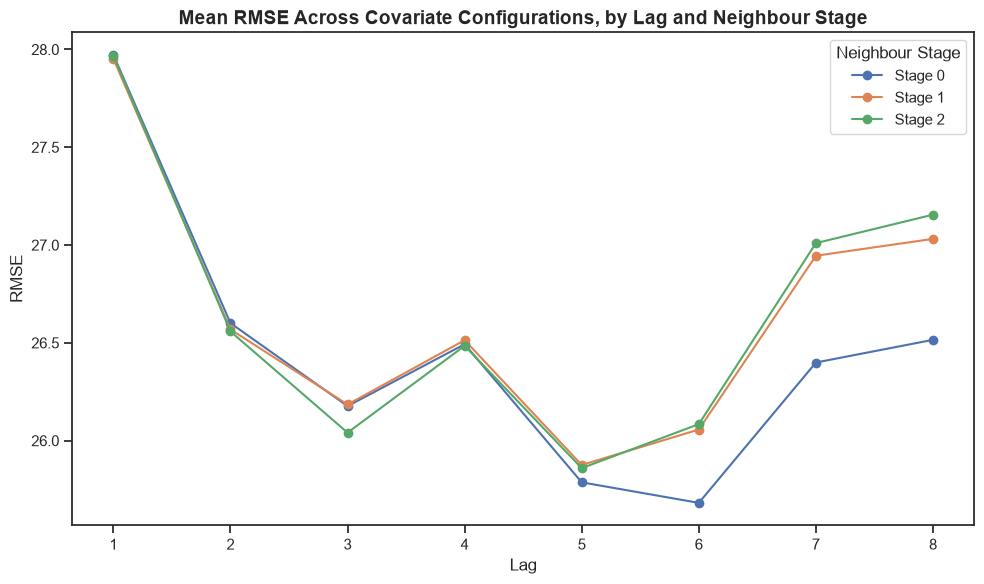

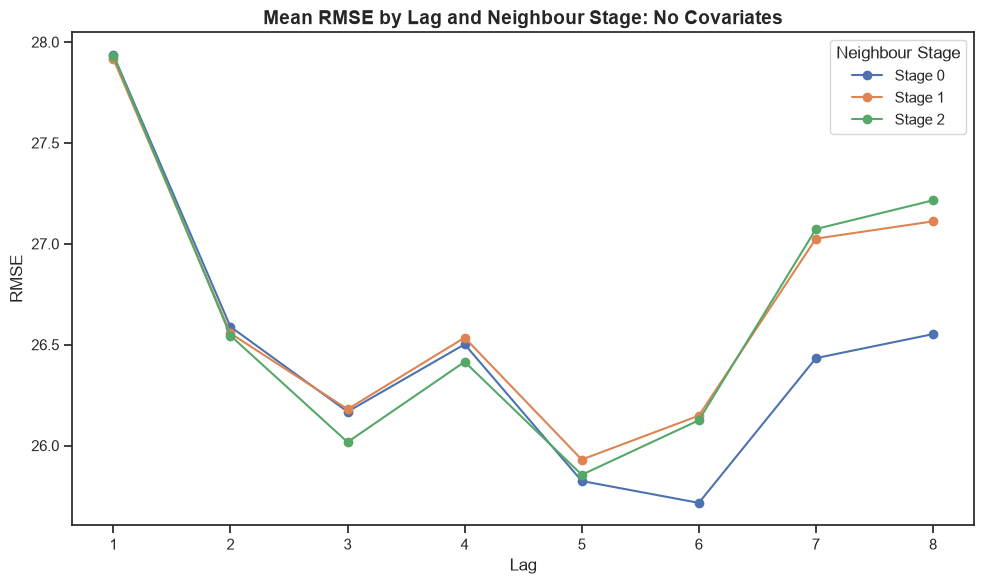

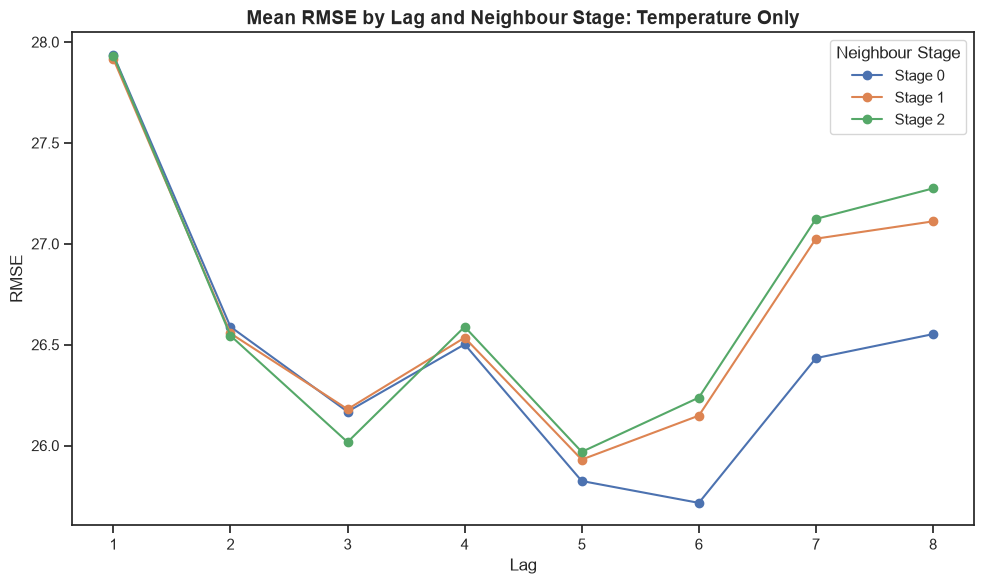

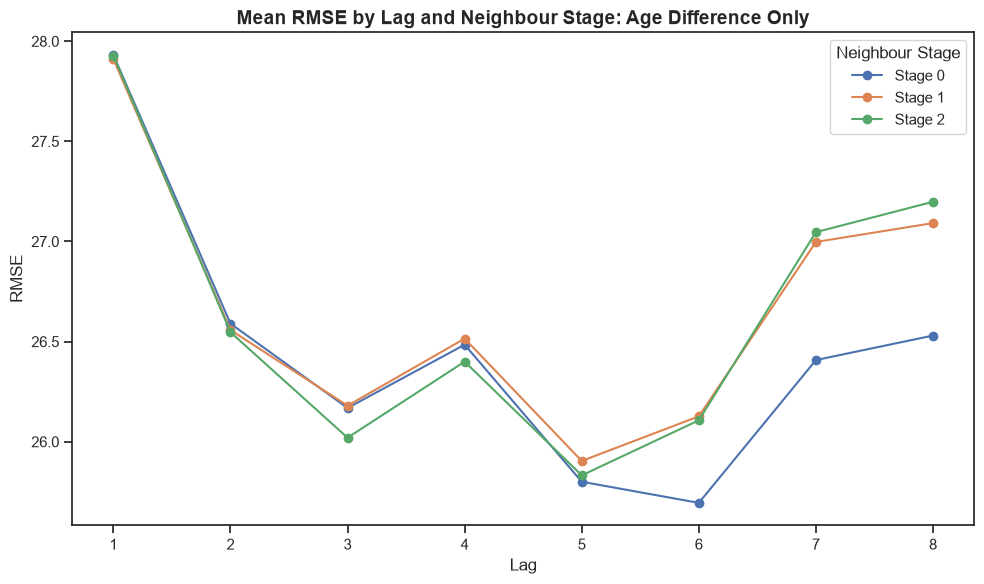

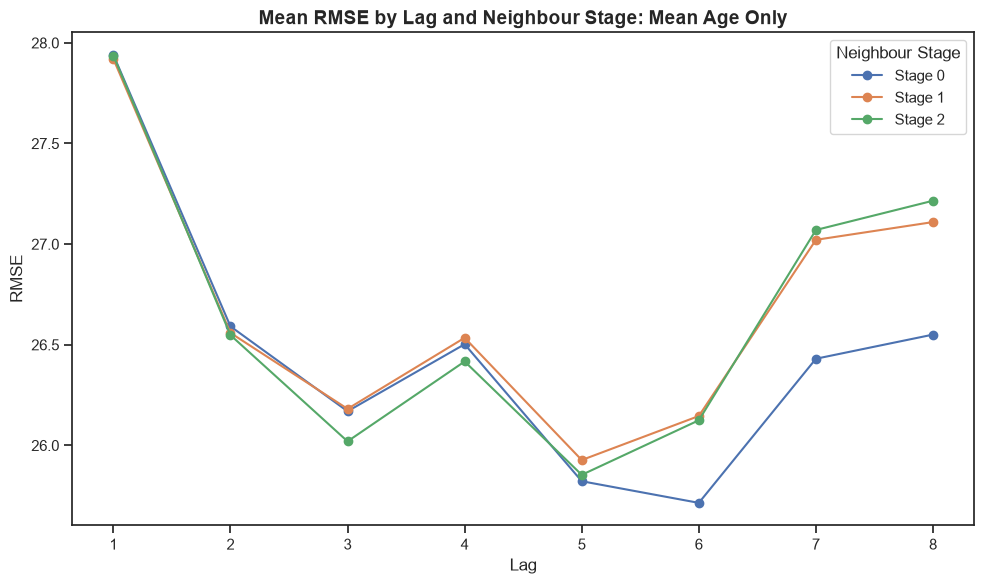

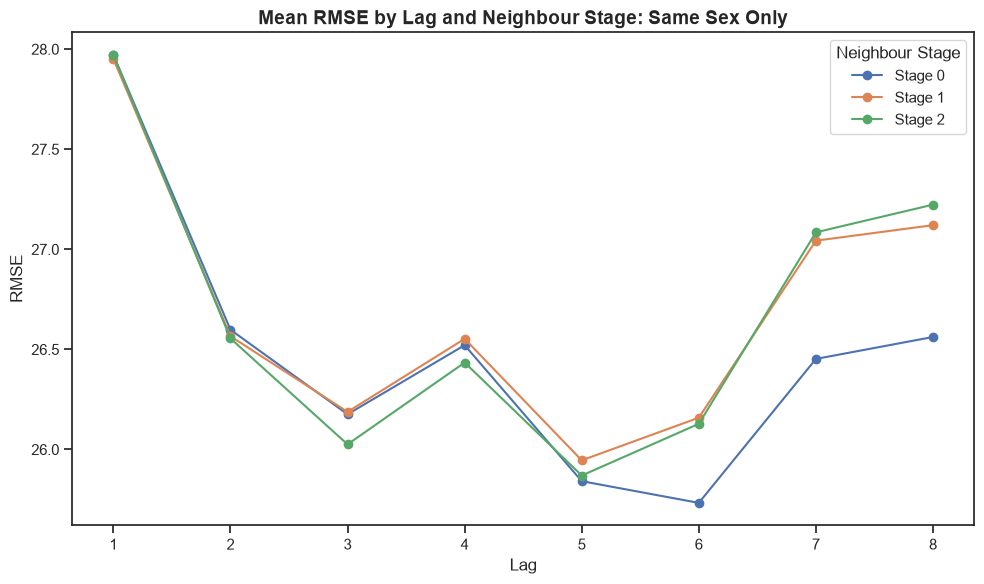

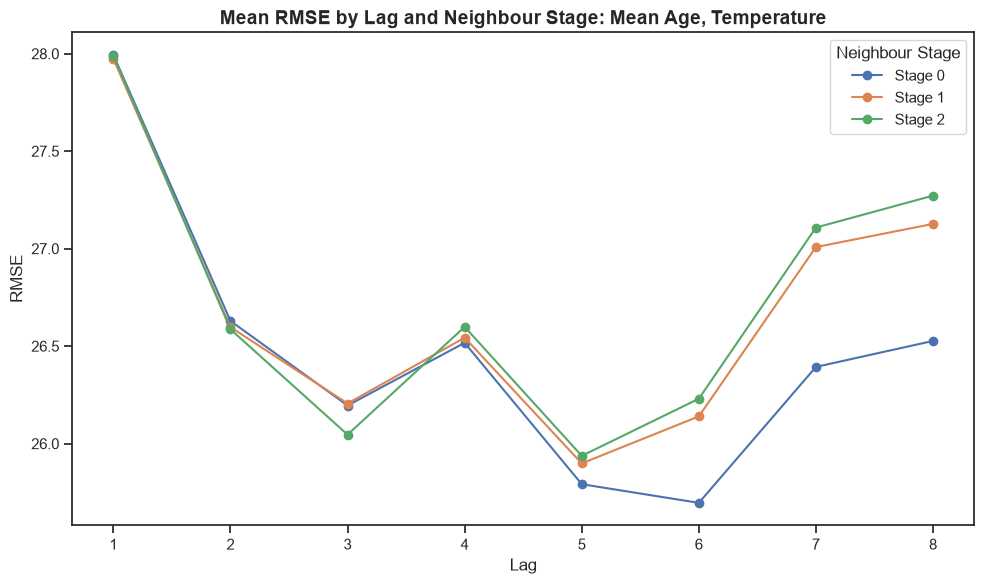

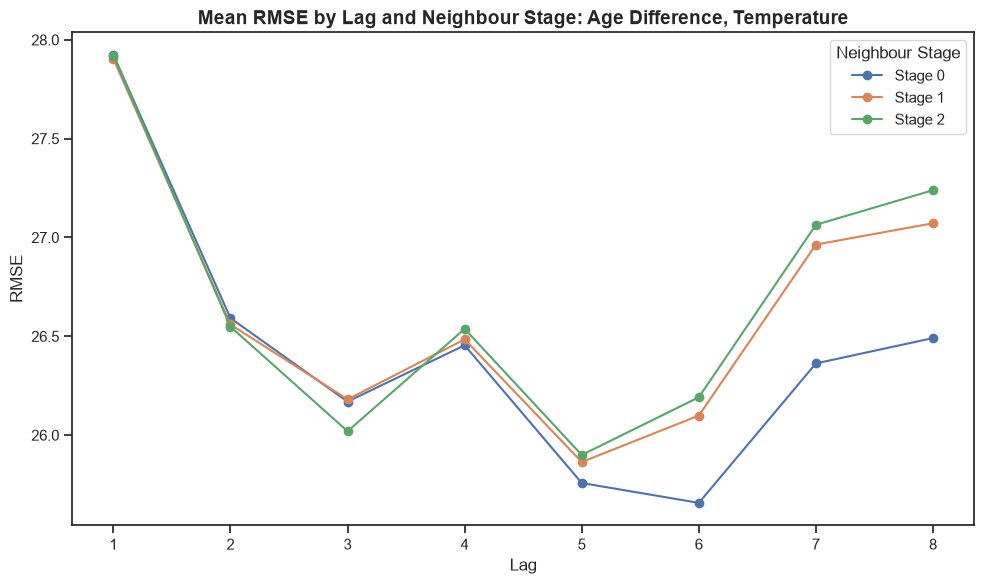

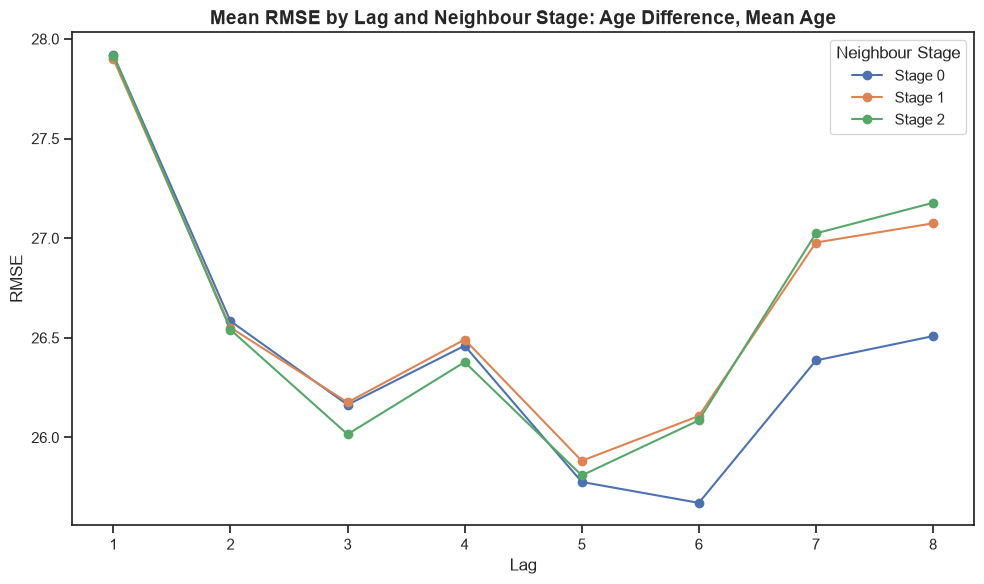

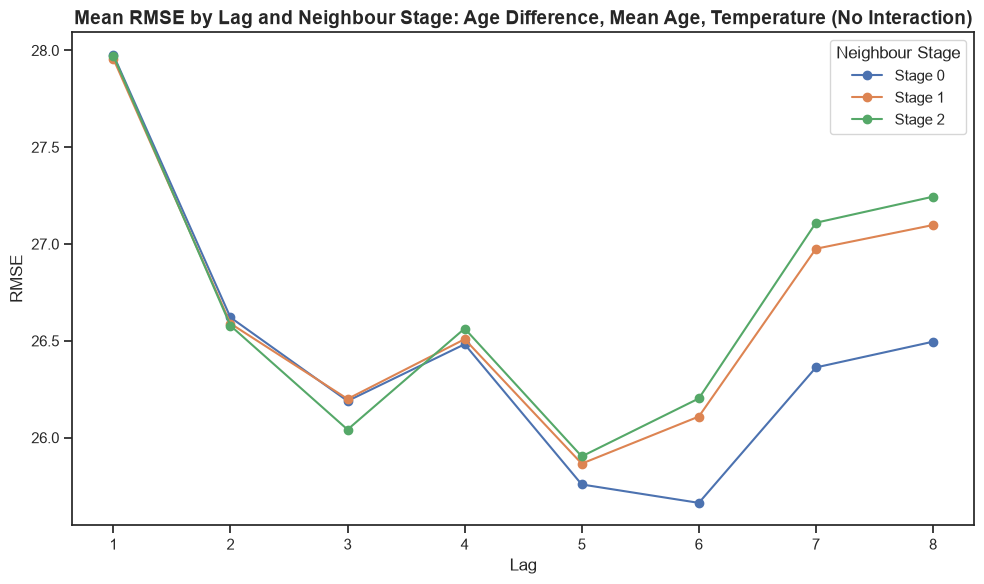

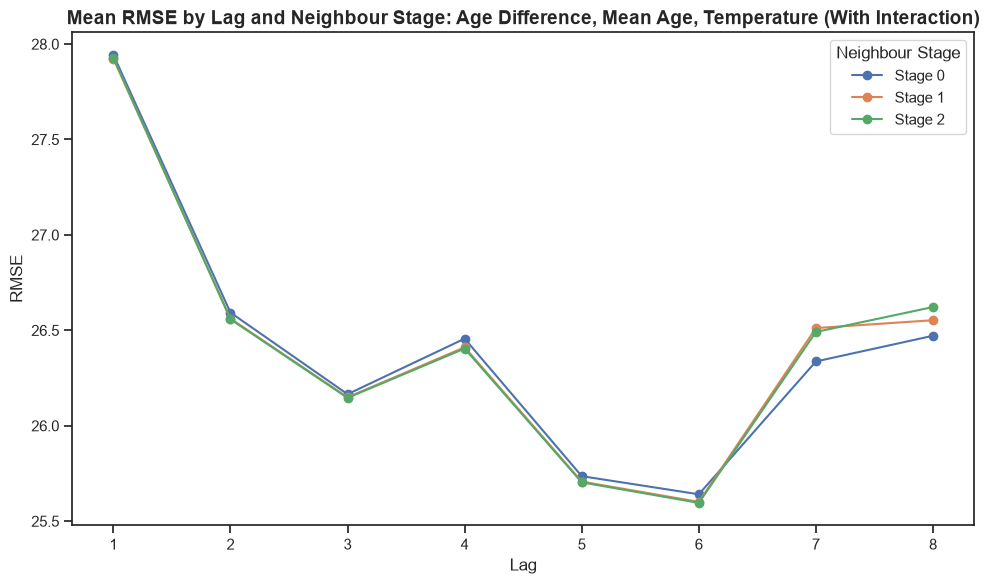

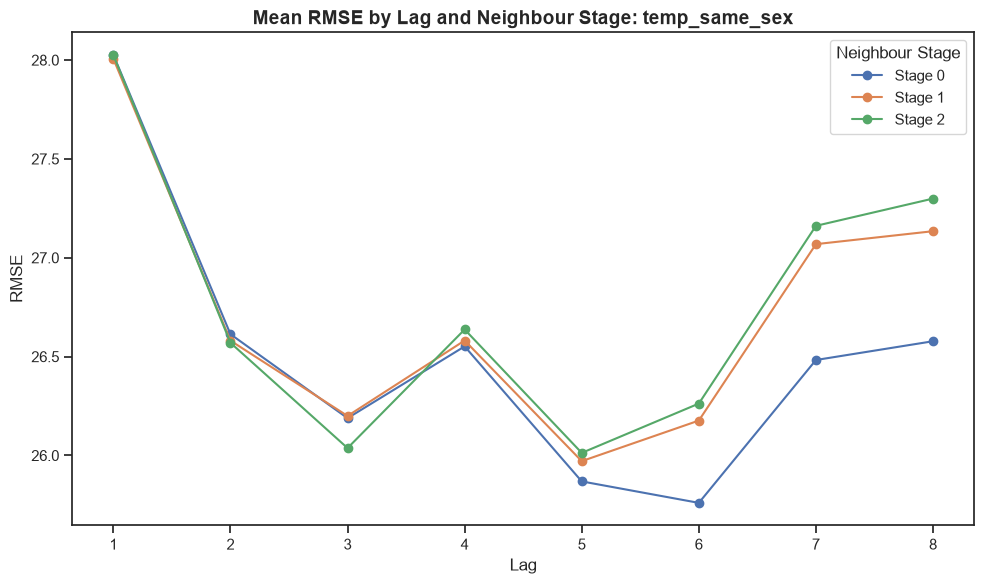

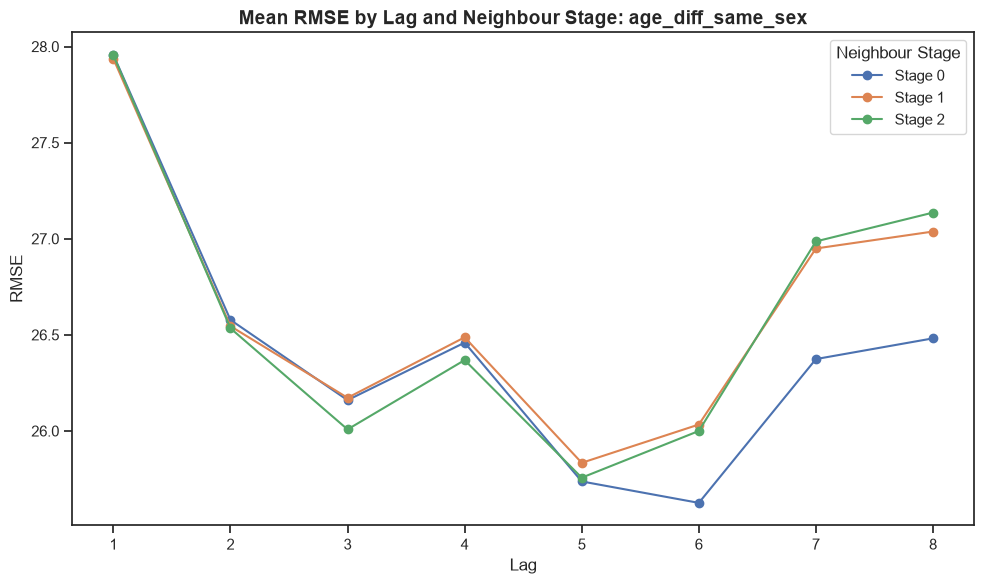

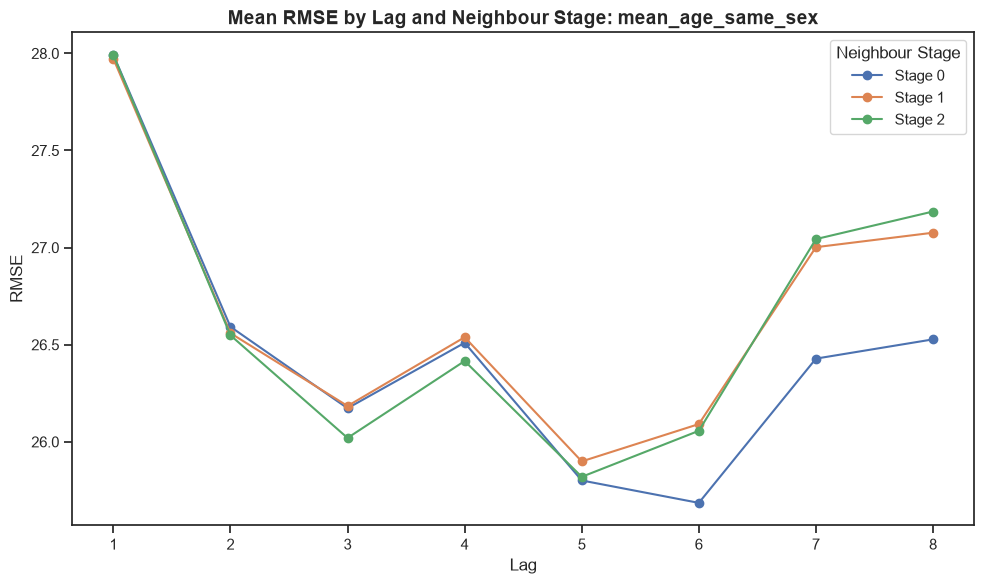

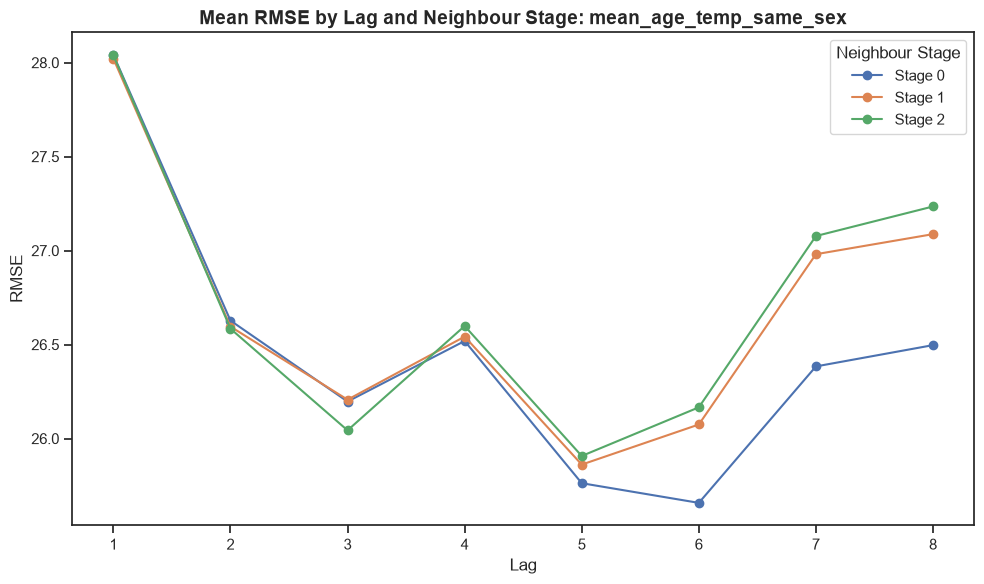

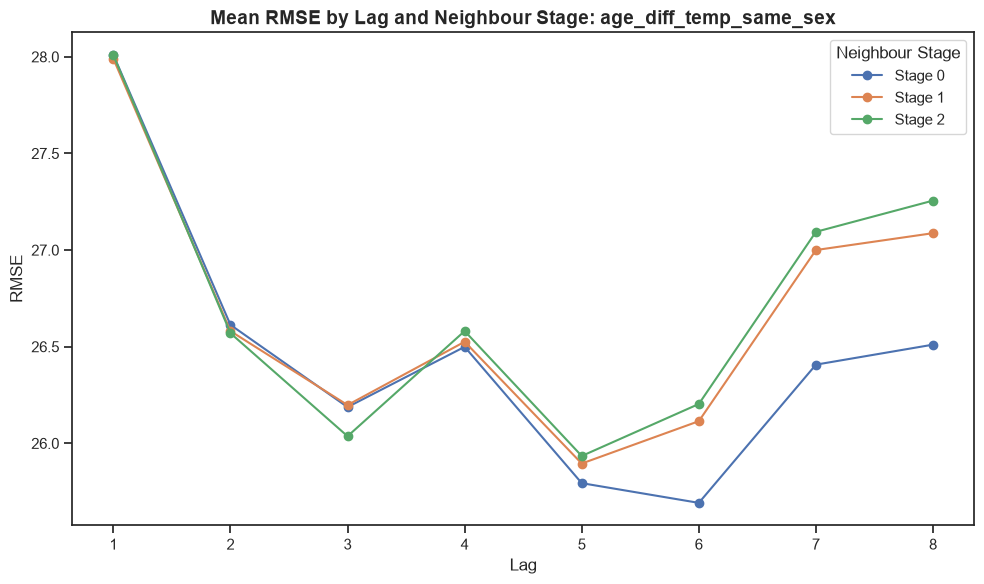

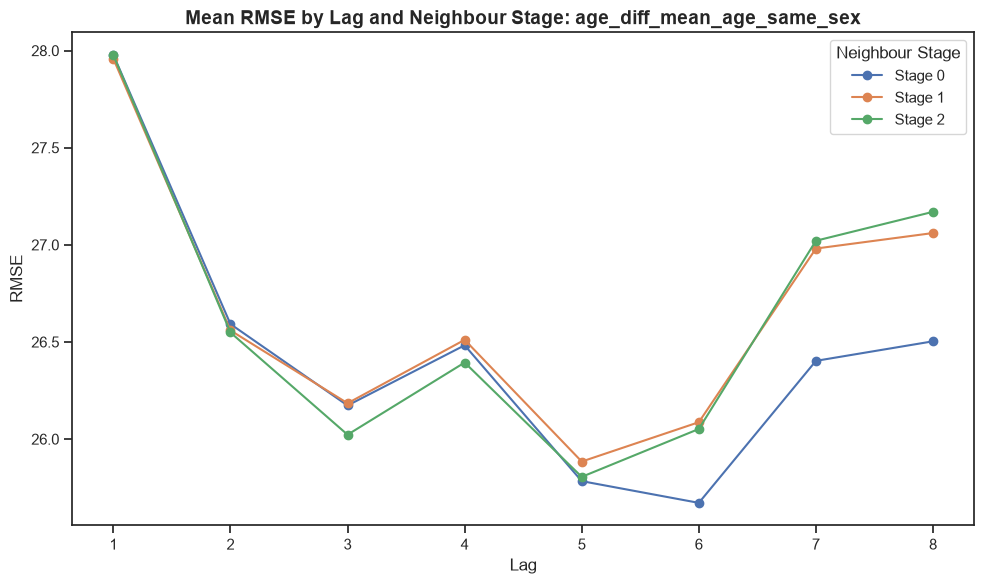

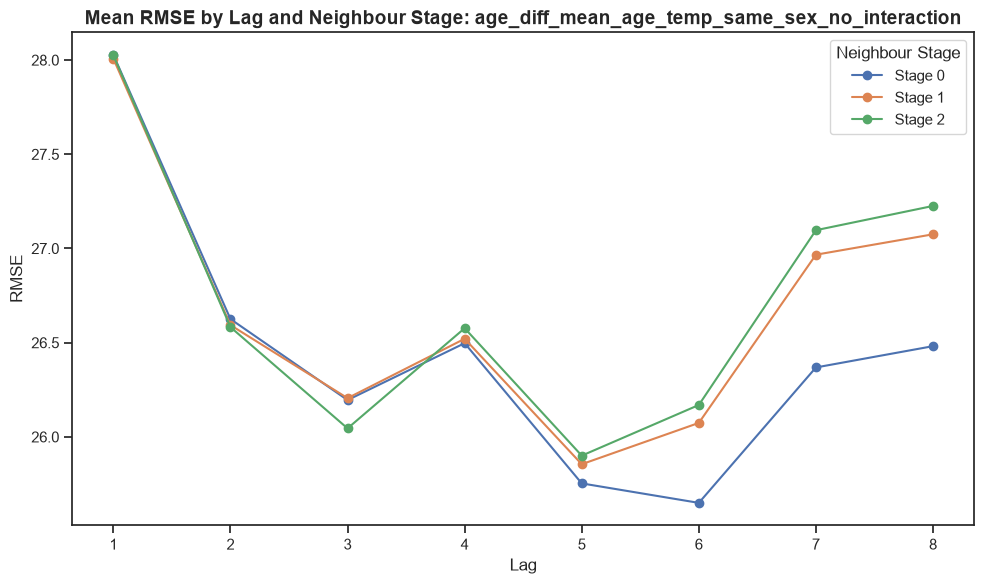

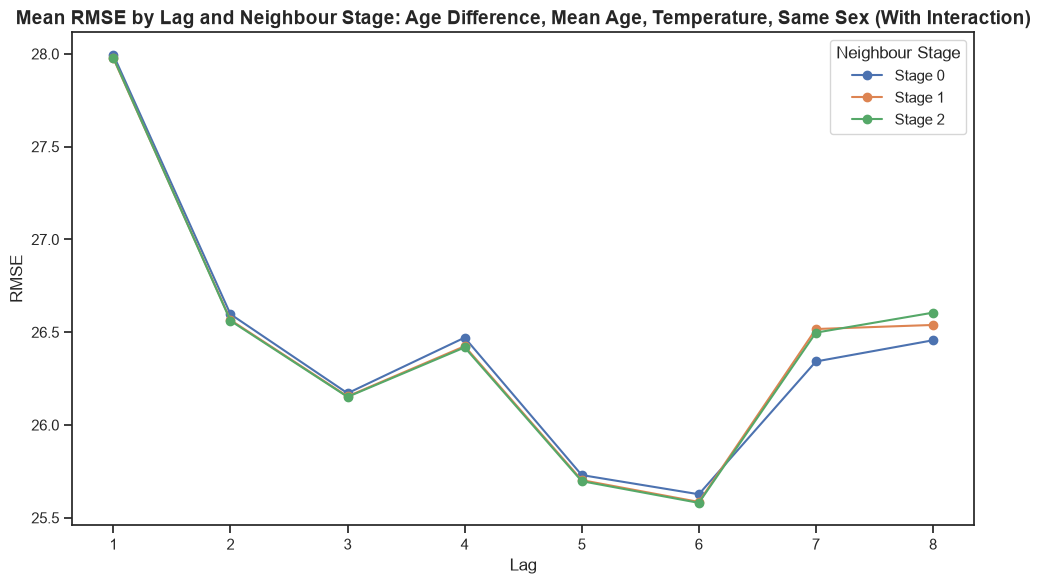

/Users/admin/baboon-gnar-edge/src/diagnostics.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


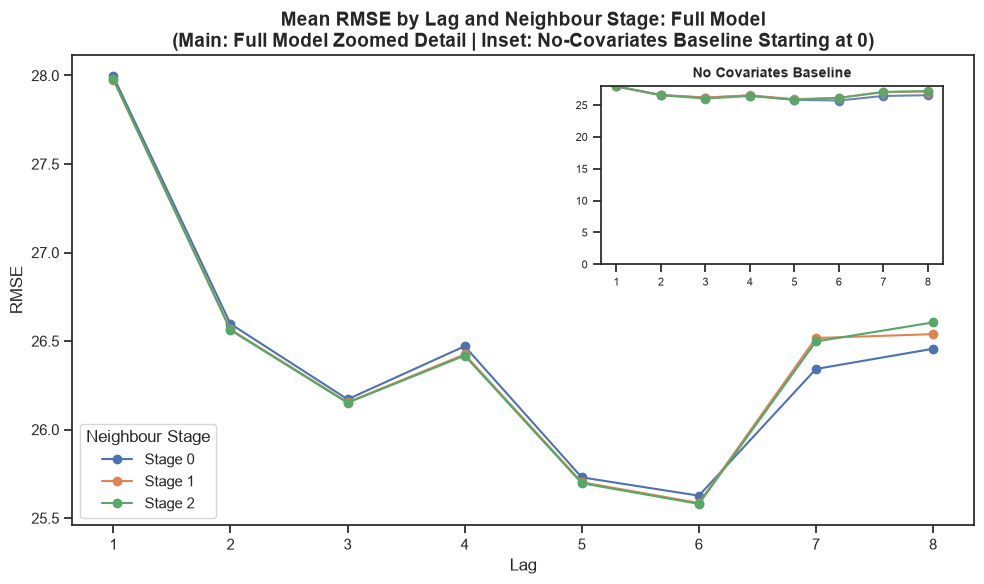

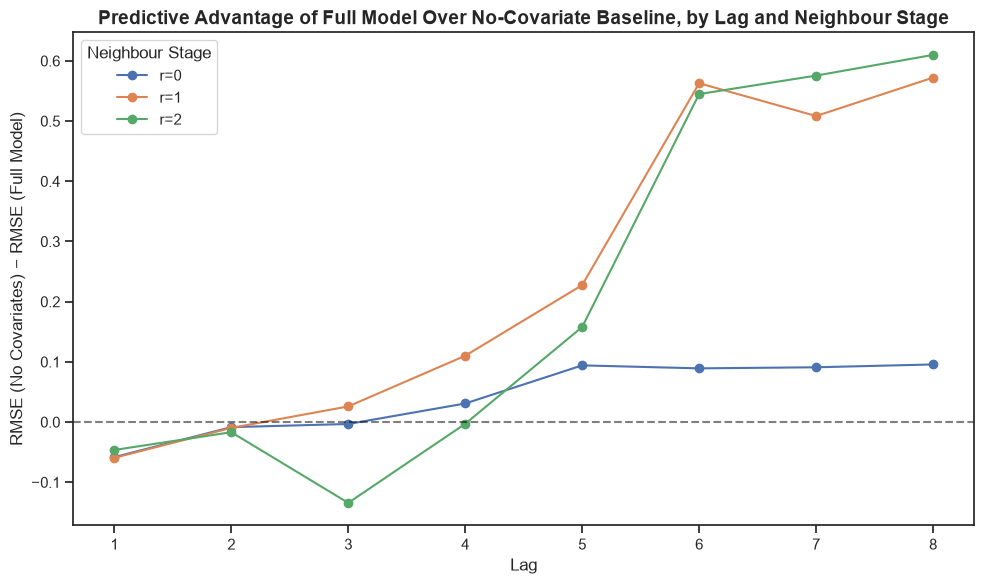

In [92]:
#1. mean rmse across covariate configurations, by lag and neighbour stage
fig = plt.figure(figsize=(10, 6))
for r in r_values:
    subset = avg_by_L_r[avg_by_L_r["r"] == r]
    plt.plot(subset["L"], subset["mean_RMSE"], marker="o", label=f"Stage {r}")

plt.xlabel("Lag", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("Mean RMSE Across Covariate Configurations, by Lag and Neighbour Stage", fontsize=14, fontweight="bold")
plt.legend(title="Neighbour Stage")
save_figure(fig, "rmse_by_lag_stage_all_configs")
plt.show()

#2. mean rmse by lag and neighbour stage, one plot per covariate configuration
config_display_names = {
    "no_covariates": "No Covariates",
    "temp_only": "Temperature Only",
    "age_diff_only": "Age Difference Only",
    "mean_age_only": "Mean Age Only",
    "same_sex_only": "Same Sex Only",
    "age_diff_mean_age": "Age Difference, Mean Age",
    "age_diff_temp": "Age Difference, Temperature",
    "mean_age_temp": "Mean Age, Temperature",
    "age_diff_mean_age_temp_no_interaction": "Age Difference, Mean Age, Temperature (No Interaction)",
    "age_diff_mean_age_temp_with_interaction": "Age Difference, Mean Age, Temperature (With Interaction)",
    "age_diff_mean_age_temp_same_sex_with_interaction": "Age Difference, Mean Age, Temperature, Same Sex (With Interaction)"
}

for config in configs:
    config_label = config["label"]
    one_config = sweep_df[sweep_df["covariate_config"] == config_label]

    if one_config.empty:
        print(f"Skipping {config_label}: No matching data found in DataFrame.")
        continue

    display_name = config_display_names.get(config_label, config_label)

    pivot = one_config.pivot(index="r", columns="L", values="mean_RMSE")

    fig = plt.figure(figsize=(10, 6))
    for r in r_values:
        if r in pivot.index:
            rmse_series = pivot.loc[r]
            plt.plot(rmse_series.index, rmse_series.values, marker="o", label=f"Stage {r}")

    plt.xlabel("Lag", fontsize=12)
    plt.ylabel("RMSE", fontsize=12)
    plt.title(f"Mean RMSE by Lag and Neighbour Stage: {display_name}", fontsize=14, fontweight="bold")
    plt.legend(title="Neighbour Stage")
    save_figure(fig, f"rmse_by_lag_stage_{config_label.lower()}")
    plt.show()

# 2b. main zoomed plot with inset starting at 0
full_cfg = "age_diff_mean_age_temp_same_sex_with_interaction"
base_cfg = "no_covariates"

df_full = sweep_df[sweep_df["covariate_config"] == full_cfg].pivot(index="r", columns="L", values="mean_RMSE")
df_base = sweep_df[sweep_df["covariate_config"] == base_cfg].pivot(index="r", columns="L", values="mean_RMSE")

fig, ax_main = plt.subplots(figsize=(10, 6))

# main plot: full model (zoomed tight on data range)
for r in r_values:
    if r in df_full.index:
        ax_main.plot(df_full.columns, df_full.loc[r].values, marker="o", label=f"Stage {r}")

ax_main.set_xlabel("Lag", fontsize=12)
ax_main.set_ylabel("RMSE", fontsize=12)
ax_main.set_title("Mean RMSE by Lag and Neighbour Stage: Full Model\n(Main: Full Model Zoomed Detail | Inset: No-Covariates Baseline Starting at 0)", fontsize=14, fontweight="bold")
ax_main.legend(title="Neighbour Stage", loc="lower left")

# inset plot: no covariates baseline (starting explicitly at y = 0)
ax_inset = inset_axes(ax_main, width="38%", height="38%", loc="upper right", borderpad=2)

for r in r_values:
    if r in df_base.index:
        ax_inset.plot(df_base.columns, df_base.loc[r].values, marker="o", alpha=0.85)

ax_inset.set_title("No Covariates Baseline", fontsize=10, fontweight="bold")
ax_inset.tick_params(labelsize=8)

# force the inset y-axis to start strictly at 0
ax_inset.set_ylim(bottom=0)

save_figure(fig, "rmse_full_model_with_nocovariates_inset_zero_start")
plt.show()

#3. predictive advantage of full model over no-covariate baseline
configs_to_compare = ["no_covariates", "age_diff_mean_age_temp_same_sex_with_interaction"]

fig = plt.figure(figsize=(10, 6))
for r in [0, 1, 2]:
    subset = sweep_df[(sweep_df["covariate_config"].isin(configs_to_compare)) & (sweep_df["r"] == r)]
    pivot = subset.pivot(index="L", columns="covariate_config", values="mean_RMSE")
    diff = pivot["no_covariates"] - pivot["age_diff_mean_age_temp_same_sex_with_interaction"]
    plt.plot(diff.index, diff.values, marker="o", label=f"r={r}")

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.xlabel("Lag", fontsize=12)
plt.ylabel("RMSE (No Covariates) − RMSE (Full Model)", fontsize=12)
plt.title("Predictive Advantage of Full Model Over No-Covariate Baseline, by Lag and Neighbour Stage", fontsize=14, fontweight="bold")
plt.legend(title="Neighbour Stage")
save_figure(fig, "rmse_advantage_full_model_vs_no_covariates")
plt.show()

***Comparing performance to baseline models (DFM, ARIMA, GNAR no-neighbours)***

DFM sweep to find best-performing "n_factors" setting

In [9]:
#build the raw count graph for baselines (no transform or normalisation)
graph_raw, windows, persistent_pair_list, X_level_raw = build_baboon_edge_graph(
    edge_threshold=1.0, timestamp="1D", n_rolling_test=5,
    path=interactions_path,
)
print(f"EdgeGraph (raw): E={graph_raw.n_edges} edges, K={graph_raw.n_nodes} nodes, T={graph_raw.n_times} periods")
val_frac_equivalent = 5 / len(windows)

dfm_sweep_results = []

#number of factors under consideration
for n_factors in [1, 2, 3]:
    #creating table to compare mae and rmse for each n_factors
    table_n = compare_baselines(
        graph_raw,
        models={
            "naive": (NaiveEdgeBaseline, {}),
            "dfm": (DFMEdgeBaseline, dict(n_factors=n_factors, factor_order=1, method="pca")),
        },
        val_frac=val_frac_equivalent, reference="naive",
    )
    row = table_n[table_n["model"] == "dfm"].iloc[0]
    dfm_sweep_results.append({"n_factors": n_factors, "MAE": row["MAE"], "RMSE": row["RMSE"]})

print(pd.DataFrame(dfm_sweep_results))

EdgeGraph (raw): E=34 edges, K=13 nodes, T=28 periods
[compare] running naive (NaiveEdgeBaseline) ...
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.004s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.003s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.003s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.003s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.005s stop=per_edge_closed_form
[compare] running dfm (DFMEdgeBaseline) ...
[DFMEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=None train_set_time=nans fit_time=0.000s stop=dfm_closed_form
[DFMEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=None train_set_time=nans fit_time=0.000

/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeW

Comparing best performing GNAR-edge model to naive persistence, ARIMA(auto), ARIMA(1,0,0) and DFM

In [ ]:
#run ARIMA and DFM baselines directly on raw counts


arima_table = compare_baselines(
    graph_raw,
    models={
        "naive": (NaiveEdgeBaseline, {}),
        "arima(1,0,0)": (ARIMAEdgeBaseline, dict(order=(1, 0, 0))),
        "arima(auto)": (ARIMAEdgeBaseline, dict(order="auto", auto_ic="aic")),
        "dfm": (DFMEdgeBaseline, dict(n_factors=1, factor_order=1, method="pca", idiosyncratic="ar1")),
    },
    val_frac=val_frac_equivalent,
    reference="naive",
)
print(arima_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

#running chosen GNAR-edge specifications (differenced, normalised, back-converted internally)
_, _, _, summary_full, _, _ = run_gnar_edge_rolling_multicov(
    **base_kwargs_fixed, L=6, stages_per_lag=build_stages_per_lag(6, 2),
    edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
    exog_series_dict=interaction_cfg["exog_series_dict"],
    interaction_pairs=interaction_cfg["interaction_pairs"],
    use_ols=True, verbose=False,
)

_, _, _, summary_nocov, _, _ = run_gnar_edge_rolling_multicov(
    **base_kwargs_fixed, L=6, stages_per_lag=build_stages_per_lag(6, 0),
    edge_cov_kinds=[], exog_series_dict={}, interaction_pairs=[],
    use_ols=True, verbose=False,
)

#assembling the final comparison table, all on raw-count scale
final_table = pd.DataFrame([
    {"model": "Extended GNAR-edge, with covariates (L=6, r=2)",
     "MAE": summary_full["mean_MAE"], "RMSE": summary_full["mean_RMSE"]},
    {"model": "Baseline GNAR-edge, no covariates (L=6, r=0)",
     "MAE": summary_nocov["mean_MAE"], "RMSE": summary_nocov["mean_RMSE"]},
])

#pulling ARIMA/naive rows directly from arima_table (already raw-count scale)
arima_rows = arima_table[["model", "MAE", "RMSE"]]

final_table = pd.concat([final_table, arima_rows], ignore_index=True).sort_values("RMSE")
final_table = final_table[["model","RMSE"]]
display(final_table)

EdgeGraph (raw): E=34 edges, K=13 nodes, T=28 periods
[compare] running naive (NaiveEdgeBaseline) ...
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.014s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.009s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.007s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.007s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.007s stop=per_edge_closed_form
[compare] running arima(1,0,0) (ARIMAEdgeBaseline) ...


/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  return 0
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  return 0
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  return 0
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  return 0
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  return 0
/Users/admin/baboon-gnar-edge/external/edge_baselin

[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=456.326802786005 train_set_time=nans fit_time=2.183s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=372.2873772371258 train_set_time=nans fit_time=2.017s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=389.4691967932592 train_set_time=nans fit_time=1.357s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=301.76328120107576 train_set_time=nans fit_time=1.191s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1978.8554168677972 train_set_time=nans fit_time=1.305s stop=per_edge_closed_form
[compare] running arima(auto) (ARIMAEdgeBaseline) ...
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=502.70021461143756 train_set_time=nans fit_time=14.493s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=425.08099180747996 train_set_time=na

,model,RMSE
0,"Extended GNAR-edge, with covariates (L=6, r=2)",25.580106
1,"Baseline GNAR-edge, no covariates (L=6, r=0)",25.715716
2,dfm,29.559763
3,"arima(1,0,0)",29.922262
4,arima(auto),31.790252
5,naive,38.534782


Exporting table to latex

In [57]:
final_table_display = final_table[["model","RMSE"]]

final_table_display.to_latex(tables_dir / "real_data_baseline_arima.tex",
                                 escape = True,
        multicolumn = True,
        multirow = True,
        caption = "Performance comparison between the best-performing extended GNAR-edge model and various baseline models."  
)

***Assessing Model Fit***

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00039185 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00039184689302925303 train_set_time=nans fit_time=0.308s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00038020 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003802046811114696 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00037068 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003706799846316214 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00036032 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003603196657721193 train_set_time=n

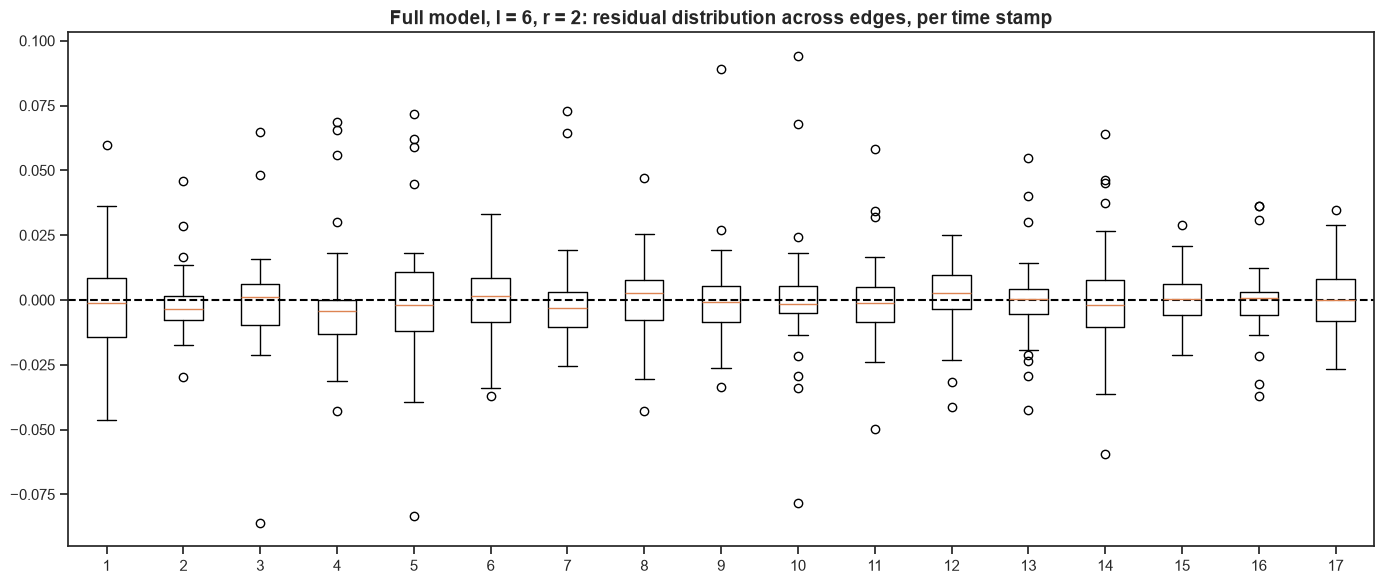

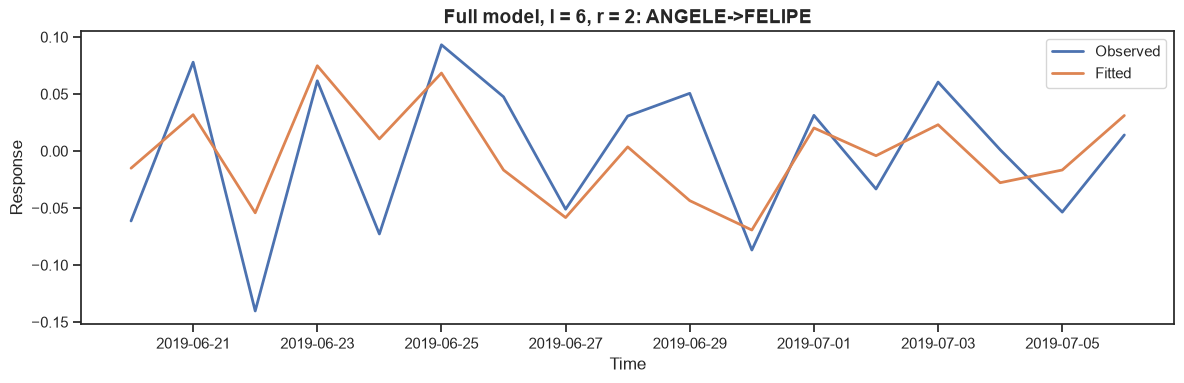

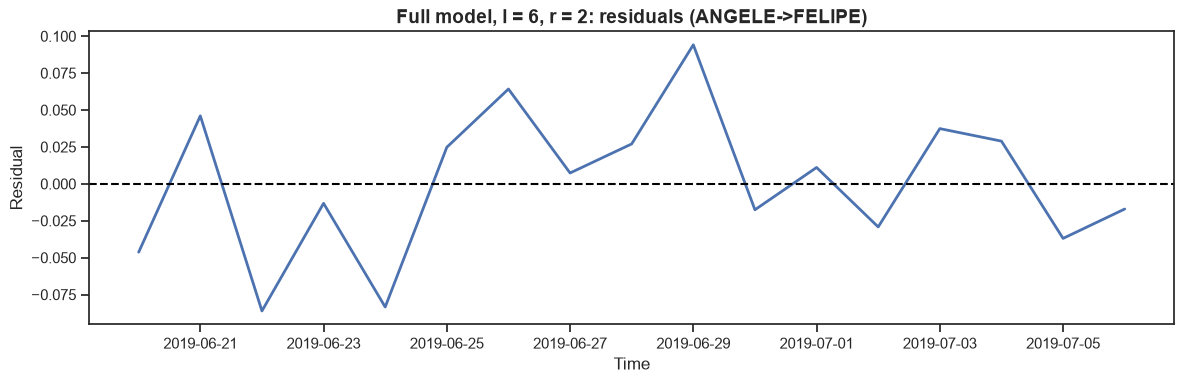

Outliers (2 std dev): 43 / 578 (7.4%)


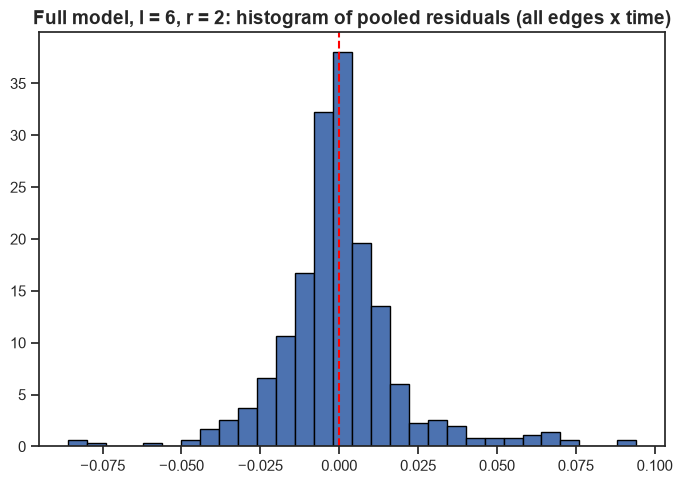

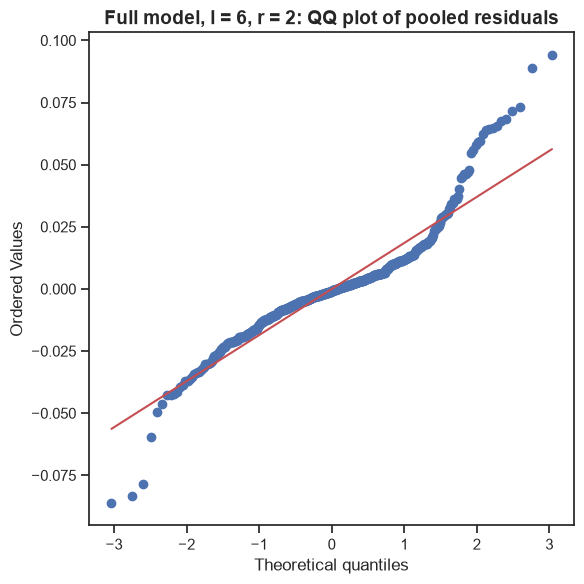

<Figure size 800x400 with 0 Axes>

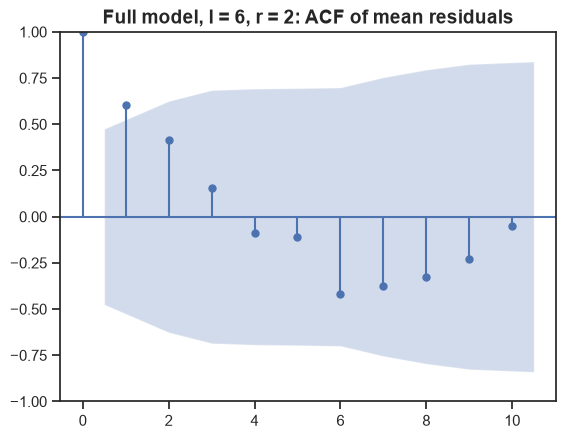


Edge-wise residual/exogenous correlations
       correlation
count    34.000000
mean      0.058172
std       0.315169
min      -0.375588
25%      -0.197980
50%       0.038774
75%       0.279150
max       0.701343


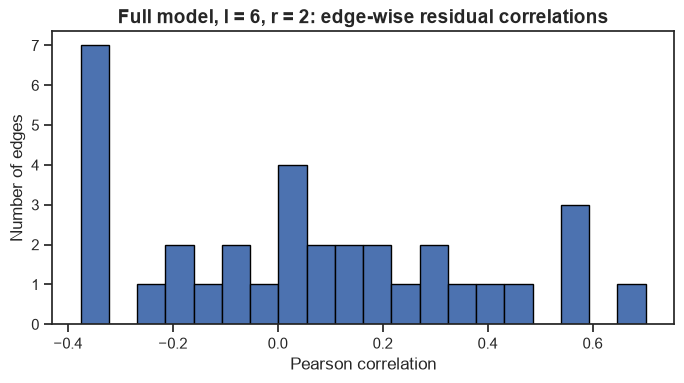

In [93]:
interaction_cfg = {"label": "age_diff_mean_age_temp_same_sex_with_interaction",
     "edge_cov_kinds": ["abs_diff", "mean", "same_sex"],
     "exog_series_dict": {"temp_max_lag1": temp_lag1},
     "interaction_pairs": [("mean_age", "temp_max_lag1")]}

#fitting best performing gnar-edge specification
roller, summary_df, rolling_results, summary, graph, per_edge_df = run_gnar_edge_rolling_multicov(
    timestamp="1D", L=6, stages_per_lag=[[1, 2]]*6, transform="difference", growth_epsilon=1.0,
    standardize=False, edge_threshold=1.0, n_rolling_test=5, custom_edge_pairs=None,
    verbose=False, weight_mode="proportion_edges", path=interactions_path,
    age_lookup=age_lookup, sex_lookup=sex_lookup, edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
    exog_series_dict=interaction_cfg["exog_series_dict"],
    interaction_pairs=interaction_cfg["interaction_pairs"])

learner = roller.steps[1].learner

#producing diagnostic plots
diagnostics = run_residual_diagnostics_pooled(
    learner,
    learner.train_set,
    label = "Full model, l = 6, r = 2",
    exog_series = temp_lag1,
    edges_to_plot= ["ANGELE->FELIPE"]
)

inspecting stationarity and residual correlation with exogenous series

In [53]:
diagnostics

(                      label  mean_residual  sd_residual  shapiro_stat  \
 0  Full model, l = 6, r = 2      -0.000041     0.019499      0.898979   
 
       shapiro_p  n_periods  n_edges  n_observations  
 0  4.493077e-19         17       34             578  ,
 {'max_eigenvalue_modulus': np.float64(0.7838584168916772),
  'stationary': np.True_},
     edge  correlation   p_value
 0      0    -0.115047  0.660166
 1      1    -0.033989  0.896961
 2      2    -0.369941  0.143859
 3      3     0.561530  0.018997
 4      4    -0.200233  0.440972
 5      5     0.104127  0.690844
 6      6    -0.325146  0.202862
 7      7    -0.093720  0.720513
 8      8     0.242177  0.349011
 9      9     0.403732  0.108028
 10    10    -0.262384  0.308962
 11    11     0.587731  0.013098
 12    12     0.004792  0.985436
 13    13     0.004416  0.986579
 14    14    -0.333379  0.190993
 15    15    -0.191222  0.462218
 16    16    -0.375415  0.137564
 17    17     0.365840  0.148702
 18    18     0.440413  0

***Reducing edge threshold***

Computing distribution of neighbourhoods for each threshold

In [ ]:
#defining thresholds
threshold_configs = [
    {"threshold": 0.8, "E": 63, "label": "0.8"},
    {"threshold": 0.9, "E": 47, "label": "0.9"},
    {"threshold": 1.0, "E": 34, "label": "1.0"},
]


results_rows = []
#looping over thresholds
for config in threshold_configs:
    thresh = config["threshold"]
    E = config["E"]
    total_possible = E * (E - 1)
    
    # Run the GNAR pipeline for this specific threshold
    _, _, _, _, graph_obj, _ = run_gnar_edge_rolling_multicov(
        timestamp="1D", L=1, stages_per_lag=None, transform="difference", growth_epsilon=1.0,
        standardize=False, edge_threshold=thresh, n_rolling_test=5, custom_edge_pairs=None,
        verbose=False, weight_mode="count", path="/Users/admin/Downloads/baboons_proximity_data.txt",
        age_lookup=None, sex_lookup=None, edge_cov_kinds=None,
        exog_series_dict=None, interaction_pairs=None, use_ols=True  
    )
    
    # compute density statistics for each neighborhood rank r
    for r in [1, 2, 3, 4]:
        W_r = graph_obj.neighbor_matrix(r)
        n_nonzero = np.count_nonzero(W_r)
        pct_nonzero = (n_nonzero / total_possible * 100) if total_possible > 0 else 0.0
        
        results_rows.append({
            "Edge Threshold": thresh,
            "n_edges_E": E,
            "Neighbour Stage": r,
            "nonzero_connections": n_nonzero,
            "total_possible_connections": total_possible,
            "density_pct": round(pct_nonzero, 2)
        })

# create the final summary df
neighbor_density_df = pd.DataFrame(results_rows)
display(neighbor_density_df)

# pivot table to inspect density side-by-side
display(neighbor_density_df.pivot(index="Neighbour Stage", columns="Edge Threshold", values="density_pct"))
save_table(neighbor_density_df.pivot(index="Neighbour Stage", columns="Edge Threshold", values="density_pct"),
           "real_data_threshold_neighbour_density")

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=1295.14965699 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=1295.149656991536 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=1281.14738325 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=1281.1473832463664 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=1251.78577574 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=1251.7857757398092 train_set_time=nans fit_time=0.000s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=1220.96011209 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=1220.9601120929276 train_set_time=nan

,Edge Threshold,n_edges_E,Neighbour Stage,nonzero_connections,total_possible_connections,density_pct
0,0.8,63,1,1158,3906,29.65
1,0.8,63,2,2748,3906,70.35
2,0.8,63,3,0,3906,0.00
3,0.8,63,4,0,3906,0.00
4,0.9,47,1,728,2162,33.67
5,0.9,47,2,1432,2162,66.23
6,0.9,47,3,2,2162,0.09
7,0.9,47,4,0,2162,0.00
8,1.0,34,1,416,1122,37.08
9,1.0,34,2,706,1122,62.92


Edge Threshold,0.8,0.9,1.0
Neighbour Stage,,,
1,29.65,33.67,37.08
2,70.35,66.23,62.92
3,0.00,0.09,0.00
4,0.00,0.00,0.00


Comparing MASE across thresholds, for various lag-stage configurations

In [ ]:
#lags and stages under consideration
L_values = list(range(1, 9))
r_values = list(range(0, 3))
thresholds = (1.0, 0.9, 0.8)

#only run for full model
full_config = [{"label": "age_diff_mean_age_temp_same_sex_with_interaction",
     "edge_cov_kinds": ["abs_diff", "mean", "same_sex"],
     "exog_series_dict": {"temp_max_lag1": temp_lag1},
     "interaction_pairs": [("mean_age", "temp_max_lag1")]}]

mase_sweep_df = full_mase_sweep(
    base_kwargs_fixed=base_kwargs_fixed,
    L_values=L_values,
    r_values=r_values,
    covariate_configs=full_config,
    thresholds=thresholds,
)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00048332 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00048332078503646696 train_set_time=nans fit_time=0.026s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00047008 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0004700829579555975 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00045887 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00045887074569696734 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00044984 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00044983824685270444 train_set_time

Presenting results

In [ ]:
#MASE by threshold across (L, r)
subset = mase_sweep_df[
    mase_sweep_df["covariate_config"] == full_config[0]["label"]
].copy()

pivot = subset.pivot_table(
    index=["L", "r"],
    columns="edge_threshold",
    values="MASE",
    aggfunc="mean",
)

pivot = pivot.reindex(columns=list(thresholds))

pivot["threshold_1.0_best"] = pivot[1.0].eq(pivot.min(axis=1))


# helper: safely get the winning row for each group
def safe_best_row_index(g):
    valid = g["MASE"].dropna()
    if valid.empty:
        return pd.NA
    return valid.idxmin()

best_idx = (
    mase_sweep_df
    .groupby(["covariate_config", "L", "r"], dropna=False)
    .apply(safe_best_row_index)
    .dropna()
    .astype(int)
)

best_rows = mase_sweep_df.loc[best_idx].copy()

# which threshold wins most often 
win_counts = best_rows["edge_threshold"].value_counts()


# add a best_threshold column back onto the full table 
mase_sweep_df["best_threshold"] = np.nan
mase_sweep_df.loc[best_rows.index, "best_threshold"] = best_rows["edge_threshold"].values

#  average MASE per threshold
avg_mase_by_threshold = mase_sweep_df.groupby("edge_threshold")["MASE"].mean()


# winning threshold by r 
win_by_r = (
    best_rows
    .groupby("r")["edge_threshold"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

print("#1. see how MASE-by-threshold-advantage varies across (L, r)")
display(pivot)

print("#2. which threshold wins most often, across (L,r) configurations")
display(win_counts)

print("#3. average MASE per threshold, marginalising over everything else")
display(avg_mase_by_threshold)

print("#4. does the winning threshold depend on r specifically?")
display(win_by_r)

#1. for a fixed covariate config, see how MASE-by-threshold-advantage varies across (L, r)


edge_threshold       1.0       0.9       0.8  threshold_1.0_best
L r                                                             
1 0             0.830738  0.836803  0.869145                True
  1             0.829860  0.836565  0.868918                True
  2             0.829925  0.835948  0.868808                True
2 0             0.780189  0.781347  0.815553                True
  1             0.779869  0.781163  0.815161                True
  2             0.779919  0.781052  0.814926                True
3 0             0.766946  0.763754  0.807460               False
  1             0.766412  0.762507  0.806919               False
  2             0.766075  0.762795  0.806691               False
4 0             0.773425  0.771459  0.825998               False
  1             0.772988  0.770473  0.825411               False
  2             0.773039  0.770126  0.825678               False
5 0             0.747358  0.746506  0.810642               False
  1             0.748942  0.745674  0.810704               False
  2             0.750520  0.745321  0.810182               False
6 0             0.746157  0.748741  0.824470                True
  1             0.746906  0.748806  0.824183                True
  2             0.746560  0.748558  0.823962                True
7 0             0.769442  0.769857  0.826485                True
  1             0.778896  0.774066  0.826511               False
  2             0.778330  0.774298  0.826826               False
8 0             0.772322  0.771694  0.816965               False
  1             0.777938  0.777022  0.819138               False
  2             0.784381  0.778108  0.817615               False

#2. which threshold wins most often, across the full grid


edge_threshold
0.9    14
1.0    10
Name: count, dtype: int64

#3. average MASE per threshold, marginalising over everything else -- overall summary


edge_threshold
0.8    0.824515
0.9    0.774277
1.0    0.774881
Name: MASE, dtype: float64

#4. does the winning threshold depend on r specifically? (matching your earlier finding pattern)


edge_threshold,0.9,1.0
r,,
0,0.500,0.500
1,0.625,0.375
2,0.625,0.375


***Extracting the fixed graph (including estimated parameters) from the fitted model, simulating time series on this graph, and seeing if the GNAR-edge model can recover the estimated parameters***

Fitting the model to the real data

In [19]:
#fitting the best performing model to the data (full model, L=6,r=2)
roller, summary_df, rolling_results, summary, graph, per_edge_df = run_gnar_edge_rolling_multicov(
    timestamp="1D", L=6, stages_per_lag=[[1, 2]]*6, transform="difference", growth_epsilon=1.0,
    standardize=False, edge_threshold=1.0, n_rolling_test=5, custom_edge_pairs=None,
    verbose=False, weight_mode="proportion_edges", path=interactions_path,
    age_lookup=age_lookup, sex_lookup=sex_lookup, edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
    exog_series_dict=interaction_cfg["exog_series_dict"],
    interaction_pairs=interaction_cfg["interaction_pairs"])

#using the final, most-data-informed fit as ground truth
learner_real = roller.steps[-1].learner   

#extract "true" parameters from the real fit
true_alpha_real = np.ravel(learner_real.alpha).tolist()
true_beta_dict_real = learner_real.beta
true_gamma_real = learner_real.gamma_

print("True alpha (from real fit):", true_alpha_real)
print("True beta (from real fit):", true_beta_dict_real)
print("True gamma (from real fit):", true_gamma_real)

#extract the real edge list and graph topology
real_edge_list = learner_real.edges       
K_real_actual = graph.n_nodes if hasattr(graph, "n_nodes") else len(set(i for e in real_edge_list for i in e))
E_real_actual = len(real_edge_list)
print(f"Real network: K={K_real_actual}, E={E_real_actual}")

# split true_gamma_real into edge-covariate, time-covariate, and interaction components
gamma_edge_cov_real = {
    "age_diff": true_gamma_real["age_diff"],
    "mean_age": true_gamma_real["mean_age"],
    "same_sex": true_gamma_real["same_sex"],
}
gamma_time_cov_real = {
    "temp_max_lag1": true_gamma_real["temp_max_lag1"],
}
gamma_interaction_real = {
    ("mean_age", "temp_max_lag1"):
        true_gamma_real["mean_age_X_temp_max_lag1"]
}

# convert neighbour stages to format expected by simulation function 
R_by_l_real = build_stages_per_lag(6, 2)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00039185 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00039184689302925303 train_set_time=nans fit_time=0.030s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00038020 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003802046811114696 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00037068 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003706799846316214 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00036032 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003603196657721193 train_set_time=n

Simulating time series on the edge weights of the extracted fixed graph

In [22]:
n_replications = 50
replication_tables_real_network = []

for rep in range(n_replications):
    result_table, learner, graph_r = run_fixed_network_replication(
        edge_list=real_edge_list, K=K_real_actual, L=6, stages_per_lag=R_by_l_real,
        true_alpha=true_alpha_real, true_beta_dict=true_beta_dict_real,
        true_gamma_edge_cov=gamma_edge_cov_real,
        true_gamma_time_cov=list(gamma_time_cov_real.values())[0] if gamma_time_cov_real else 0.0,
        interaction_pairs=interaction_cfg["interaction_pairs"],
        true_gamma_interaction=gamma_interaction_real,
        T=28, seed=rep,
    )
    replication_tables_real_network.append(result_table)

#presenting results in table
table4_real_network = build_aggregated_table4_style(replication_tables_real_network, n_replications)

# renaming exogenous coefficients
param_display_map = {
    "age_diff": "Age Diff",
    "mean_age": "Mean Age",
    "same_sex": "Same Sex",
    "temp_max_lag1": "Max Temp",
    "mean_age_X_temp_max_lag1": r"Mean Age $\times$ Max Temp",
}

# map alpha_i to $\alpha_{i}$
for i in range(1, 7):
    param_display_map[f"alpha{i}"] = f"$\\alpha_{{{i}}}$"

# map beta_i,j to $\beta_{i,j}$
for i in range(1, 7):
    for j in (1, 2):
        param_display_map[f"beta{i},{j}"] = f"$\\beta_{{{i},{j}}}$"

# formatting the table
table4_real_network_formatted = table4_real_network.copy()
table4_real_network_formatted["parameter"] = table4_real_network_formatted["parameter"].map(
    lambda x: param_display_map.get(x, x)
)
import pandas as pd

# ordering parameters by parameter type
alphas = [f"$\\alpha_{{{i}}}$" for i in range(1, 7)]
betas = [f"$\\beta_{{{i},{j}}}$" for i in range(1, 7) for j in (1, 2)]
covariates = ["Age Diff", "Mean Age", "Same Sex", "Max Temp", r"Mean Age $\times$ Max Temp"]
ordered_params = alphas + betas + covariates

table4_real_network_formatted["parameter"] = pd.Categorical(
    table4_real_network_formatted["parameter"], 
    categories=ordered_params, 
    ordered=True
)

table4_real_network_formatted = table4_real_network_formatted.sort_values("parameter").reset_index(drop=True)

display(table4_real_network_formatted)

save_table(table4_real_network_formatted, "real_network_parameter_recovery")
table4_real_network_formatted.to_latex(
    tables_dir / "real_network_parameter_recovery.tex",
    index=False,
    escape=False,
    caption="Coverage rates for the estimated parameters from the real data application over 50 repetitions.",
    label="tab:real_network_parameter_recovery",
)

,parameter,Estimated,95% CI,Coverage
0,$\alpha_{1}$,-0.773749,"(-0.844, -0.703)",98%
1,$\alpha_{2}$,-0.563064,"(-0.648, -0.478)",98%
2,$\alpha_{3}$,-0.415473,"(-0.503, -0.328)",96%
3,$\alpha_{4}$,-0.373088,"(-0.458, -0.288)",96%
4,$\alpha_{5}$,-0.265949,"(-0.347, -0.185)",98%
5,$\alpha_{6}$,-0.148746,"(-0.219, -0.079)",96%
6,"$\beta_{1,1}$",0.039045,"(-0.226, 0.304)",90%
7,"$\beta_{1,2}$",-0.024550,"(-0.391, 0.342)",96%
8,"$\beta_{2,1}$",-0.073433,"(-0.390, 0.243)",96%
9,"$\beta_{2,2}$",0.009668,"(-0.430, 0.450)",96%


***Computing runtimes***

Real data application runtimes

In [12]:
real_data_timing_results = []

#GNAR-edge, full covariates + interaction (L=6, r=2)
_ = time_call(
    "GNAR-edge (L=6, r=2, all covariates)",
    lambda: run_gnar_edge_rolling_multicov(
        **base_kwargs_fixed, L=6, stages_per_lag=build_stages_per_lag(6, 2),
        edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
        exog_series_dict=interaction_cfg["exog_series_dict"],
        interaction_pairs=interaction_cfg["interaction_pairs"],
        use_ols=True, verbose=False,
    ),timing_results = real_data_timing_results
)

#GNAR-edge, no covariates (L=6, r=0)
_ = time_call(
    "GNAR-edge (L=6, r=0, no covariates)",
    lambda: run_gnar_edge_rolling_multicov(
        **base_kwargs_fixed, L=6, stages_per_lag=build_stages_per_lag(6, 0),
        edge_cov_kinds=[], exog_series_dict={}, interaction_pairs=[],
        use_ols=True, verbose=False,
    ),timing_results = real_data_timing_results
)

#ARIMA auto
_ = time_call(
    "ARIMA(auto)",
    lambda: compare_baselines(
        graph_raw,
        models={
            "naive": (NaiveEdgeBaseline, {}),
            "arima(auto)": (ARIMAEdgeBaseline, dict(order="auto")),
        },
        val_frac=val_frac_equivalent, reference="naive",
    ),
    timing_results=real_data_timing_results,
)

#ARIMA (1,0,0)
_ = time_call(
    "ARIMA(1,0,0)",
    lambda: compare_baselines(
        graph_raw,
        models={
            "naive": (NaiveEdgeBaseline, {}),
            "arima(1,0,0)": (ARIMAEdgeBaseline, dict(order=(1,0,0))),
        },
        val_frac=val_frac_equivalent, reference="naive",
    ),
    timing_results=real_data_timing_results,
)

#DFM
_ = time_call(
    "DFM (n_factors=1)",
    lambda: compare_baselines(
        graph_raw,
        models={
            "naive": (NaiveEdgeBaseline, {}),
            "dfm": (DFMEdgeBaseline, dict(n_factors=1, factor_order=1, method="pca")),
        },
        val_frac=val_frac_equivalent, reference="naive",
    ),
    timing_results=real_data_timing_results,
)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00039185 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00039184689302925303 train_set_time=nans fit_time=0.002s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00038020 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003802046811114696 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00037068 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003706799846316214 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00036032 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003603196657721193 train_set_time=n

/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeW

[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=502.70021461143756 train_set_time=nans fit_time=5.323s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=425.08099180747996 train_set_time=nans fit_time=5.475s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=301.08840804163196 train_set_time=nans fit_time=5.996s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=171.7519623717092 train_set_time=nans fit_time=5.463s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1580.0305845842377 train_set_time=nans fit_time=5.220s stop=per_edge_closed_form
ARIMA(auto): 27.50s
[compare] running naive (NaiveEdgeBaseline) ...
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.011s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.

/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeW

[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=456.326802786005 train_set_time=nans fit_time=0.489s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=372.2873772371258 train_set_time=nans fit_time=0.501s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=389.4691967932592 train_set_time=nans fit_time=0.486s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=301.76328120107576 train_set_time=nans fit_time=0.433s stop=per_edge_closed_form
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1978.8554168677972 train_set_time=nans fit_time=0.452s stop=per_edge_closed_form
ARIMA(1,0,0): 2.42s
[compare] running naive (NaiveEdgeBaseline) ...
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.004s stop=per_edge_closed_form
[NaiveEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=0.0 train_set_time=nans fit_time=0.010

/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeWarning: Mean of empty slice
  "AIC": float(np.nanmean(aic)) if len(aic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:297: RuntimeWarning: Mean of empty slice
  "BIC": float(np.nanmean(bic)) if len(bic) else np.nan,
/Users/admin/baboon-gnar-edge/external/edge_baselines.py:296: RuntimeW

Simulation experiments runtimes (moderately sized networks)

In [13]:
_rdp_radius_cache = {}

paper_regimes = {
    # gnar-edge paper regimes
    1: {"L": 1, "R_max": [1],       "alpha": [0.2],             "beta_vals": [0.3],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    2: {"L": 1, "R_max": [2],       "alpha": [0.2],             "beta_vals": [(0.3, 0.4)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    3: {"L": 3, "R_max": [1, 1, 1], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [0.2, 0.1, -0.2],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    4: {"L": 3, "R_max": [2, 2, 2], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},
    5: {"L": 3, "R_max": [2, 0, 0], "alpha": [0.2, 0.4, -0.6],  "beta_vals": [(0.3, 0.4)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.0, "interaction_pairs": [], "gamma_interaction": {}},

    # new regimes with covariates, exogenous series, and/or interactions
    6: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.0,
        "interaction_pairs": [], "gamma_interaction": {}},
    7: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],
        "gamma_edge_cov": {}, "gamma_time_cov": 0.2,
        "interaction_pairs": [], "gamma_interaction": {}},
    8: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],   #matches regime 4 exactly
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.2,
        "interaction_pairs": [], "gamma_interaction": {}},
    9: {"L": 3, "R_max": [2, 2, 2],
        "alpha": [0.2, 0.4, -0.6],
        "beta_vals": [(0.3, 0.1), (0.1, 0.1), (-0.2, 0.3)],   #matches regime 4 exactly
        "gamma_edge_cov": {"age_diff": 0.05, "mean_age": 0.03}, "gamma_time_cov": 0.2,
        "interaction_pairs": [("mean_age", "sim_temp")], "gamma_interaction": {("mean_age", "sim_temp"): 0.02}},
}


In [14]:
sim_moderate_timing_results = []

#calculate runtimes for both regime 4 and regime 9
for regime_id, regime_label in [(9, "Regime 9 (with interaction)"), (4, "Regime 4 (no covariates)")]:
    regime_spec = paper_regimes[regime_id]
    R_by_l_i = expand_R_by_l(regime_spec["R_max"])
    beta_dict_i = build_beta_dict(R_by_l_i, regime_spec["beta_vals"])

    #simulate data once, reuse for all timing runs
    edge_list_i, _ = generate_network(K=20, density=0.4, structure="ER", seed=0, rdp_radius_cache=_rdp_radius_cache)
    ages_i, sexes_i = simulate_node_covariates(K=20, seed=0)
    edge_covariates_i = build_synthetic_edge_covariates(edge_list_i, ages_i, sexes_i)
    edge_covariates_sim_i = {name: edge_covariates_i[name] for name in regime_spec["gamma_edge_cov"].keys()}
    X_sim_i, time_cov_sim_i, graph_i = simulate_full_model(
        edge_list_i, 20, regime_spec["L"], R_by_l_i, regime_spec["alpha"], beta_dict_i,
        edge_covariates_sim_i, regime_spec["gamma_edge_cov"], regime_spec["gamma_time_cov"],
        regime_spec["interaction_pairs"], regime_spec["gamma_interaction"], T=500, seed=0,
    )
    time_index_i = pd.date_range("2020-01-01", periods=500, freq="D")
    train_index_i = time_index_i[:-1]

    exog_series_sim_i = {}
    if regime_spec["gamma_time_cov"] != 0.0 or len(regime_spec["interaction_pairs"]) > 0:
        exog_series_sim_i = {"sim_temp": pd.Series(time_cov_sim_i[:-1], index=train_index_i)}

    sim_graph_i = ArrayEdgeGraph.from_edge_panel(X_sim_i[:-1, :], edge_list_i, n_nodes=20, time_labels=train_index_i)

    #helper function to calculate isolated GNAR-edge (with neighbours) timing
    def fit_gnar_with_neighbours():
        learner = GNAREdgeGlobalMultiCovLearner(
            graph=sim_graph_i, L=regime_spec["L"], stages_per_lag=R_by_l_i,
            train_periods=train_index_i, use_ols=True,
            edge_covariates=edge_covariates_sim_i, exog_series=exog_series_sim_i,
            interaction_pairs=regime_spec["interaction_pairs"],
        )
        learner.fit(use_ols=True, verbose=False)
        return learner

    #helper function to calculate isolated GNAR-edge (NO neighbours) timing
    def fit_gnar_no_neighbours():
        stages_no_neighbour = [[] for _ in range(regime_spec["L"])]
        learner = GNAREdgeGlobalMultiCovLearner(
            graph=sim_graph_i, L=regime_spec["L"], stages_per_lag=stages_no_neighbour,
            train_periods=train_index_i, use_ols=True,
            edge_covariates=edge_covariates_sim_i, exog_series=exog_series_sim_i,
            interaction_pairs=regime_spec["interaction_pairs"],
        )
        learner.fit(use_ols=True, verbose=False)
        return learner

    #isolated GNAR-edge (with neighbours) timing
    _ = time_call(f"{regime_label}: Extended GNAR-edge, with neighbours (isolated)",
                 fit_gnar_with_neighbours, timing_results=sim_moderate_timing_results)

    #isolated GNAR-edge (no neighbours) timing
    _ = time_call(f"{regime_label}: Extended GNAR-edge, no neighbours (isolated)",
                 fit_gnar_no_neighbours, timing_results=sim_moderate_timing_results)

    #isolated ARIMA(auto) timing
    _ = time_call(
        f"{regime_label}: ARIMA(auto), isolated",
        lambda: compare_baselines(sim_graph_i, models={"arima(auto)": (ARIMAEdgeBaseline, dict(order="auto"))},
                                  val_frac=1/499, reference="auto"),
        timing_results=sim_moderate_timing_results,
    )

    #isolated DFM timing
    train_data_i = X_sim_i[:-1, :]
    def fit_dfm():
        return dfm_pca_one_step(train_data_i, n_factors=1, factor_order=1, idiosyncratic="ar1", standardize=True)

    _ = time_call(f"{regime_label}: DFM (isolated)",
                 fit_dfm, timing_results=sim_moderate_timing_results)

Regime 9 (with interaction): Extended GNAR-edge, with neighbours (isolated): 0.04s
Regime 9 (with interaction): Extended GNAR-edge, no neighbours (isolated): 0.04s
[compare] running arima(auto) (ARIMAEdgeBaseline) ...
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1.9618865784040878 train_set_time=nans fit_time=44.950s stop=per_edge_closed_form
Regime 9 (with interaction): ARIMA(auto), isolated: 44.98s
Regime 9 (with interaction): DFM (isolated): 0.24s
Regime 4 (no covariates): Extended GNAR-edge, with neighbours (isolated): 0.04s
Regime 4 (no covariates): Extended GNAR-edge, no neighbours (isolated): 0.02s
[compare] running arima(auto) (ARIMAEdgeBaseline) ...
[ARIMAEdgeBaseline] fit_done epochs=1 best_epoch=1 best_loss=1.938344919718071 train_set_time=nans fit_time=45.389s stop=per_edge_closed_form
Regime 4 (no covariates): ARIMA(auto), isolated: 45.43s
Regime 4 (no covariates): DFM (isolated): 0.25s


Exporting results to Latex

In [15]:

real_data_timing_df = pd.DataFrame(real_data_timing_results)
sim_moderate_timing_df= pd.DataFrame(sim_moderate_timing_results)


# split the experiment string into regime and task (ie model)
sim_moderate_timing_df["regime"] = sim_moderate_timing_df["experiment"].str.extract(
    r"^(Regime \d+ \([^)]+\))"
)
sim_moderate_timing_df["task"] = sim_moderate_timing_df["experiment"].str.split(": ", n=1).str[1]

# wide format: one column per regime
sim_moderate_wide = (
    sim_moderate_timing_df.pivot(index="task", columns="regime", values="runtime_seconds")
    .reset_index()
)

sim_moderate_wide.columns.name = None
sim_moderate_wide = sim_moderate_wide.rename(columns={"task": "Model"})

#converting to 2dp for latex
sim_moderate_wide_fmt = sim_moderate_wide.copy()
for col in sim_moderate_wide_fmt.columns:
    if col != "Model":
        sim_moderate_wide_fmt[col] = sim_moderate_wide_fmt[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "-")

sim_moderate_wide_fmt.to_latex(
    tables_dir / "sim_moderate_timing.tex",
    index=False,
    escape=False,
    caption="Runtime comparison for moderate-network simulations.",
    label="tab:sim_moderate_timing",
)

#formatting real data table for latex
real_data_timing_fmt = real_data_timing_df.copy()
if "runtime_seconds" in real_data_timing_fmt.columns:
    real_data_timing_fmt["runtime_seconds"] = real_data_timing_fmt["runtime_seconds"].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else "-"
    )

real_data_timing_fmt.to_latex(
    tables_dir / "real_data_timing.tex",
    index=False,
    escape=False,
    caption="Runtime comparison for the real-data analysis.",
    label="tab:real_data_timing",
)


display(real_data_timing_df)
display(sim_moderate_timing_df)

,experiment,runtime_seconds
0,"GNAR-edge (L=6, r=2, all covariates)",0.390439
1,"GNAR-edge (L=6, r=0, no covariates)",0.325074
2,ARIMA(auto),27.503807
3,"ARIMA(1,0,0)",2.424162
4,DFM (n_factors=1),0.045305


,experiment,runtime_seconds,regime,task
0,Regime 9 (with interaction): Extended GNAR-edg...,0.041565,Regime 9 (with interaction),"Extended GNAR-edge, with neighbours (isolated)"
1,Regime 9 (with interaction): Extended GNAR-edg...,0.037837,Regime 9 (with interaction),"Extended GNAR-edge, no neighbours (isolated)"
2,"Regime 9 (with interaction): ARIMA(auto), isol...",44.982075,Regime 9 (with interaction),"ARIMA(auto), isolated"
3,Regime 9 (with interaction): DFM (isolated),0.244493,Regime 9 (with interaction),DFM (isolated)
4,"Regime 4 (no covariates): Extended GNAR-edge, ...",0.036850,Regime 4 (no covariates),"Extended GNAR-edge, with neighbours (isolated)"
5,"Regime 4 (no covariates): Extended GNAR-edge, ...",0.018552,Regime 4 (no covariates),"Extended GNAR-edge, no neighbours (isolated)"
6,"Regime 4 (no covariates): ARIMA(auto), isolated",45.431053,Regime 4 (no covariates),"ARIMA(auto), isolated"
7,Regime 4 (no covariates): DFM (isolated),0.254644,Regime 4 (no covariates),DFM (isolated)


In [31]:
print(sys.version)
print(sys.executable)

3.13.13 (main, Apr 11 2026, 13:37:54) [Clang 14.0.0 (clang-1400.0.29.102)]
/Users/admin/.venv/bin/python


***Investigating whether the canonical labelling creates artefacts***

In [35]:
#building a dataframe: one row per baboon, with name and age
baboon_names = sorted(age_lookup.keys())   #alphabetical order
alphabetical_rank = {name: i for i, name in enumerate(baboon_names)}

df_check = pd.DataFrame({
    "name": list(age_lookup.keys()),
    "age": list(age_lookup.values()),
    "sex": list(sex_lookup.values()),
    "alphabetical_rank": [
        alphabetical_rank[n]
        for n in age_lookup.keys()
    ],
})

#correlation between alphabetical rank and age
r, p = pearsonr(
    df_check["alphabetical_rank"],
    df_check["age"].astype(float),
)
print(
    f"Correlation between alphabetical rank and age: "
    f"r={r:.3f}, p={p:.3f}"
)


#correlation between alphebetical rank and sex
sex_map = {"F": 0, "M": 1}
df_check["sex_binary"] = df_check["sex"].map(sex_map)

if df_check["sex_binary"].isna().any():
    print("Unexpected sex values:", df_check.loc[
        df_check["sex_binary"].isna(), "sex"
    ].unique())
else:
    r_sex, p_sex = pearsonr(
        df_check["alphabetical_rank"],
        df_check["sex_binary"],
    )
    print(
        f"Correlation between alphabetical rank and sex: "
        f"r={r_sex:.3f}, p={p_sex:.3f}"
    )

Correlation between alphabetical rank and age: r=0.216, p=0.478
Correlation between alphabetical rank and sex: r=0.178, p=0.560


Comparing performance for canonical labelling vs bidirectional network

In [32]:
#canonical (single-direction) version 
roller_canonical, _, _, summary_canonical, _, _ = run_gnar_edge_rolling_multicov(
    L=6,
    stages_per_lag=build_stages_per_lag(6, 2),
    weight_mode="proportion_edges",
    path=interactions_path,
    age_lookup=age_lookup,
    sex_lookup=sex_lookup,
    edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
    exog_series_dict=interaction_cfg["exog_series_dict"],
    interaction_pairs=interaction_cfg["interaction_pairs"],
    use_ols=True,
    verbose=False,
    bidirectional=False,
)

#bidirectional version
roller_bidir, _, _, summary_bidir, _, _ = run_gnar_edge_rolling_multicov(
    L=6,
    stages_per_lag=build_stages_per_lag(6, 2),
    weight_mode="proportion_edges",
    path=interactions_path,
    age_lookup=age_lookup,
    sex_lookup=sex_lookup,
    edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
    exog_series_dict=interaction_cfg["exog_series_dict"],
    interaction_pairs=interaction_cfg["interaction_pairs"],
    use_ols=True,
    verbose=False,
    bidirectional=True,
)

comparison = pd.DataFrame([
    {
        "model": "Canonical (single-direction)",
        "n_edges": summary_canonical["n_edges"],
        "MAE": summary_canonical["mean_MAE"],
        "RMSE": summary_canonical["mean_RMSE"],
    },
    {
        "model": "Bidirectional",
        "n_edges": summary_bidir["n_edges"],
        "MAE": summary_bidir["mean_MAE"],
        "RMSE": summary_bidir["mean_RMSE"],
    },
])

display(comparison)
save_table(
    comparison,
    "canonical_vs_bidirectional_comparison"
)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00039185 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00039184689302925303 train_set_time=nans fit_time=0.011s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00038020 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003802046811114696 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00037068 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003706799846316214 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00036032 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003603196657721193 train_set_time=n

,model,n_edges,MAE,RMSE
0,Canonical (single-direction),34,18.804536,25.580106
1,Bidirectional,68,21.088676,27.965651


***seasonal differencing***

identifying optimal lag and neighbour stage for full model under seasonal differencing

In [85]:
#range of lag and neighbour stages considered
L_values_seasonal = list(range(1, 7))   
r_values_seasonal = list(range(0, 3))   
seasonal_sweep_results = []

for L in L_values_seasonal:
    for r in r_values_seasonal:
        stages = build_stages_per_lag(L, r)

        try:
            roller, summary_df, rolling_results, summary, graph, per_edge_df = run_gnar_edge_rolling_multicov(
                timestamp="1D", L=L, stages_per_lag=stages,
                transform="seasonal_difference", seasonal_period=7,
                weight_mode="proportion_edges", edge_threshold=1.0, n_rolling_test=5,
                path=interactions_path,
                age_lookup=age_lookup, sex_lookup=sex_lookup,
                edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
                exog_series_dict=interaction_cfg["exog_series_dict"],
                interaction_pairs=interaction_cfg["interaction_pairs"],
                use_ols=True, verbose=False,
            )

            seasonal_sweep_results.append({
                "L": L, "r": r,
                "mean_MAE": summary["mean_MAE"],
                "mean_RMSE": summary["mean_RMSE"],
                "std_MAE": summary["std_MAE"],
                "std_RMSE": summary["std_RMSE"],
                "min_n_train_samples": rolling_results["n_train_samples"].min(),
                "status": "ok",
            })

        except Exception as e:
            seasonal_sweep_results.append({
                "L": L, "r": r,
                "mean_MAE": np.nan, "mean_RMSE": np.nan,
                "std_MAE": np.nan, "std_RMSE": np.nan,
                "min_n_train_samples": np.nan,
                "status": f"failed: {type(e).__name__}: {e}",
            })

seasonal_sweep_df = pd.DataFrame(seasonal_sweep_results)
display(seasonal_sweep_df)

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00070983 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0007098292068935497 train_set_time=nans fit_time=0.024s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00071168 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0007116838985489778 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00068870 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0006887039269573885 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00066339 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0006633942566948964 train_set_time=na

,L,r,mean_MAE,mean_RMSE,std_MAE,std_RMSE,min_n_train_samples,status
0,1,0,26.861920,39.284810,8.954758,14.178183,15,ok
1,1,1,26.862437,39.091241,8.847591,14.202256,15,ok
2,1,2,26.867846,39.106329,8.852349,14.221266,15,ok
3,2,0,27.061400,39.127003,9.085804,14.040989,14,ok
4,2,1,27.250466,39.223258,9.038169,13.983535,14,ok
5,2,2,27.253227,39.237841,9.022496,13.984387,14,ok
6,3,0,27.050655,39.112060,8.532001,13.660241,13,ok
7,3,1,27.435105,39.306436,8.698069,13.807947,13,ok
8,3,2,27.429565,39.327159,8.690890,13.827992,13,ok
9,4,0,27.144764,39.168826,8.404869,13.435981,12,ok


Comparing optimal first differenced model to optimal seasonal differenced model

In [87]:
#print each individual rolling step's RMSE (first differencing)
roller_difference, summary_df, rolling_results_difference, summary_difference, graph, per_edge_df = run_gnar_edge_rolling_multicov(
    L=6, stages_per_lag=build_stages_per_lag(6, 2),
    transform="difference",
    weight_mode="proportion_edges", edge_threshold=1.0, n_rolling_test=5,
    path=interactions_path, age_lookup=age_lookup, sex_lookup=sex_lookup, edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
        exog_series_dict=interaction_cfg["exog_series_dict"],
        interaction_pairs=interaction_cfg["interaction_pairs"], verbose=False,
)
print("first difference:", rolling_results_difference[["step", "target_period", "MAE", "RMSE", "n_train_samples"]])
print("first difference mean RMSE:", summary_difference["mean_RMSE"])

#print each individual rolling step's RMSE (seasonal differencing)
roller_seasonal, summary_df, rolling_results_seasonal, summary_seasonal, graph, per_edge_df = run_gnar_edge_rolling_multicov(
    L=1, stages_per_lag=build_stages_per_lag(1, 1),
    transform="seasonal_difference", seasonal_period=7,
    weight_mode="proportion_edges", edge_threshold=1.0, n_rolling_test=5,
    path=interactions_path,age_lookup=age_lookup, sex_lookup=sex_lookup, edge_cov_kinds=interaction_cfg["edge_cov_kinds"],
        exog_series_dict=interaction_cfg["exog_series_dict"],
        interaction_pairs=interaction_cfg["interaction_pairs"], verbose=False,
)
print("seasonal difference:", rolling_results[["step", "target_period", "MAE", "RMSE", "n_train_samples"]])
print("seasonal difference mean RMSE:", summary_seasonal["mean_RMSE"])

[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00039185 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.00039184689302925303 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00038020 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003802046811114696 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00037068 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003706799846316214 train_set_time=nans fit_time=0.001s stop=ols_closed_form
[GNAREdgeGlobalMultiCovLearner] epoch=001 loss=0.00036032 time=0.000s no_improve_rounds=0 low_gain_rounds=0
[GNAREdgeGlobalMultiCovLearner] fit_done epochs=1 best_epoch=1 best_loss=0.0003603196657721193 train_set_time=n